# **Análise Estatística do Mercado Global de Videogames: Fatores Determinantes do Sucesso Comercial**

## *Investigando a correlação entre avaliações críticas e desempenho de vendas dos principais títulos do mercado*

---

**Autores:** Wagner Victor Alves de Menezes, Victor Gabriel Ribeiro Jacome

**Instituição:** Universidade Federal de Goiás - Instituto de Matemática e Estatística

**Disciplina:** Probabilidade e Estatística A

**Professora:** Amanda B. G. Milani

**Data:** 25/11/2025

---

## **Resumo**

A indústria de videogames representa um dos mercados de entretenimento mais lucrativos globalmente, movimentando mais de 180 bilhões de dólares anuais. Este estudo investiga os fatores que influenciam o sucesso comercial de videogames através de uma análise estatística abrangente dos **Top 2000 jogos mais vendidos** entre 1993 e 2018. Utilizando dados do VGChartz, aplicamos técnicas de estatística descritiva e regressão linear simples para quantificar a relação entre avaliações da crítica especializada (`critic_score`) e o desempenho de vendas globais (`total_sales`). A análise focou em jogos comercialmente relevantes para garantir maior confiabilidade dos dados e representatividade do mercado mainstream. Os resultados revelam padrões importantes sobre a evolução temporal do mercado, distribuição geográfica das vendas, e a influência das avaliações críticas no desempenho comercial. Adicionalmente, uma análise de resíduos foi conduzida para validar as premissas estatísticas do modelo de regressão, fornecendo insights valiosos para desenvolvedoras, publishers e pesquisadores do setor.

---

## **Conjunto de Dados**

**Fonte:** VGChartz 2024 - Video Game Sales Dataset  
**Plataforma:** Kaggle  
**Link:** https://www.kaggle.com/datasets/asaniczka/video-game-sales-2024  

### **Dados Originais**
- **Período completo:** 1971 - 2024  
- **Registros totais:** 64.016 jogos  

---

## **Metodologia de Preparação dos Dados**

### **Processo de Limpeza e Transformação**

Para garantir a qualidade e confiabilidade das análises estatísticas, o dataset original passou por um processo estruturado de preparação de dados, documentado integralmente no notebook `01_limpeza_dados.ipynb`. As principais etapas foram:

#### **1. Seleção Inicial**
- **Filtragem temporal:** Remoção de jogos anteriores a 1993 (dados escassos e pouco representativos).
- **Filtragem por completude:** Seleção apenas de jogos com `critic_score` e `total_sales` válidos.
- **Ranqueamento:** Ordenação por vendas globais decrescentes.

#### **2. Amostragem Estratégica**
- **Critério:** Seleção dos **Top 2000** jogos mais vendidos.
- **Justificativa:** Foco em títulos comercialmente relevantes com maior probabilidade de dados completos e confiáveis. Jogos de nicho ou com vendas mínimas frequentemente apresentam dados incompletos ou inconsistentes.

#### **3. Transformações Aplicadas**
- **Criação da variável `year`:** Extração do ano a partir da coluna `release_date` original.
- **Remoção de colunas desnecessárias:** `img` (URL de imagens) e `last_update` (metadados administrativos).

#### **4. Tratamento de Valores Ausentes**

| Variável | % Nulos Original | Ação Tomada | Justificativa |
|:---|:---:|:---|:---|
| `jp_sales` | 51.2% | **Removida** | Comprometeria análises regionais; ausência indica baixa rastreabilidade no mercado japonês |
| `na_sales` | 2.8% | Preenchida com 0 | Representa ausência de vendas rastreadas |
| `pal_sales` | 2.1% | Preenchida com 0 | Representa ausência de vendas rastreadas |
| `other_sales` | 1.9% | Preenchida com 0 | Representa ausência de vendas rastreadas |

---

## **Dicionário de Dados:**

Esta seção detalha as variáveis presentes no conjunto de dados, fornecendo contexto sobre sua medição e interpretação estatística.

---

### **Variáveis Comerciais (Quantitativas Contínuas)**

#### **Vendas Globais**

* `total_sales`
    * **Descrição:** Volume total de vendas físicas e digitais do jogo em escala global.
    * **Unidade:** Milhões de unidades vendidas.
    * **Interpretação:** Métrica principal de sucesso comercial. Valores mais altos indicam maior penetração de mercado e rentabilidade.

#### **Vendas por Região**

* `na_sales`
    * **Descrição:** Vendas consolidadas na região da América do Norte.
    * **Abrangência:** Estados Unidos, Canadá e México.
    * **Unidade:** Milhões de unidades vendidas.

* `pal_sales`
    * **Descrição:** Vendas nas regiões que utilizam o sistema PAL de transmissão.
    * **Abrangência:** Europa, África, Oceania e partes da Ásia.
    * **Unidade:** Milhões de unidades vendidas.

* `other_sales`
    * **Descrição:** Vendas em mercados não contemplados pelas categorias anteriores.
    * **Abrangência:** Principalmente América Latina e mercados asiáticos emergentes.
    * **Unidade:** Milhões de unidades vendidas.

#### **Avaliação Crítica**

* `critic_score`
    * **Descrição:** Nota média agregada atribuída por veículos especializados de crítica de videogames.
    * **Metodologia:** Média ponderada de avaliações de sites como IGN, GameSpot, Polygon e outros.
    * **Unidade:** Escala decimal de 0.0 a 10.0.
    * **Interpretação:** Valores mais altos indicam melhor recepção da crítica especializada. Notas acima de 8.0 geralmente indicam excelência técnica e artística.

---

### **Variável Temporal (Quantitativa Discreta)**

* `year`
    * **Descrição:** Ano de lançamento comercial do jogo.
    * **Formato:** Ano civil (AAAA).
    * **Intervalo:** 1993 a 2018 (26 anos de histórico de mercado).
    * **Interpretação:** Permite análise de evolução temporal da indústria e identificação de tendências por era/geração de consoles.

---

### **Variáveis Categóricas (Qualitativas)**

#### **Plataforma**

* `console`
    * **Descrição:** Sistema de hardware no qual o jogo foi lançado.
    * **Categorias:** 23 plataformas únicas no dataset.
    * **Exemplos:** PlayStation 4, Xbox One, Nintendo Switch, PC, PlayStation 3, Xbox 360, Wii, etc.
    * **Interpretação:** Permite comparação de desempenho entre ecossistemas (Sony vs. Microsoft vs. Nintendo vs. PC).

#### **Gênero**

* `genre`
    * **Descrição:** Classificação do jogo por categoria de gameplay e mecânicas.
    * **Categorias:** 18 gêneros únicos conforme taxonomia VGChartz.
    * **Exemplos:** Action, Sports, Shooter, Role-Playing (RPG), Racing, Adventure, Fighting, etc.
    * **Interpretação:** Identifica preferências do mercado e nichos mais lucrativos.

#### **Publicadora**

* `publisher`
    * **Descrição:** Empresa responsável pela publicação, marketing e distribuição do jogo.
    * **Categorias:** 84 publishers únicos no dataset.
    * **Exemplos:** Nintendo, Electronic Arts (EA), Activision, Ubisoft, Sony Interactive Entertainment, etc.
    * **Interpretação:** Gigantes da indústria com maior poder de mercado e capacidade de investimento.

#### **Desenvolvedora**

* `developer`
    * **Descrição:** Estúdio ou empresa responsável pelo desenvolvimento técnico e criativo do jogo.
    * **Categorias:** 400 desenvolvedores únicos no dataset.
    * **Exemplos:** Nintendo EAD, Rockstar North, Naughty Dog, CD Projekt Red, FromSoftware, etc.
    * **Interpretação:** Identifica estúdios de excelência e possíveis correlações entre desenvolvedor e sucesso crítico/comercial.

---

### **Classificação Estatística das Variáveis**

Para fins de análise estatística, as variáveis são classificadas como:

**Variáveis Quantitativas Contínuas (5):**
- `critic_score`, `total_sales`, `na_sales`, `pal_sales`, `other_sales`

**Variável Quantitativa Discreta (1):**
- `year`

**Variáveis Qualitativas Nominais (4):**
- `console`, `genre`, `publisher`, `developer`

## **1. Instalação das Dependências**

As células abaixo instalam e configuram todas as bibliotecas Python necessárias para a análise estatística.

In [1]:
# Importação das bibliotecas padrão para análise de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import linregress

# Configuração de warnings (opcional - limpa output)
import warnings
warnings.filterwarnings('ignore')

# Definição do estilo visual para os gráficos
sns.set_style('whitegrid')
sns.set_palette('viridis')

# Configurações de exibição do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print("✅ Bibliotecas importadas com sucesso!")
print(f"📦 Pandas versão: {pd.__version__}")
print(f"📦 NumPy versão: {np.__version__}")

✅ Bibliotecas importadas com sucesso!
📦 Pandas versão: 2.3.3
📦 NumPy versão: 2.3.4


## **2. Carregamento do Dataset Limpo**

Carregamos o dataset previamente preparado e exibimos informações estruturais para verificação da integridade dos dados.

In [2]:
# Carregamento do dataset limpo
df_clean = pd.read_csv('../data/processed/vgchartz_clean.csv')

print("="*60)
print("📊 DATASET CARREGADO COM SUCESSO!")
print("="*60)
print(f"📈 Total de registros: {len(df_clean):,}")
print(f"📋 Total de variáveis: {len(df_clean.columns)}")
print(f"🗓️ Período analisado: {df_clean['year'].min()} - {df_clean['year'].max()}")
print(f"🎮 Total de jogos únicos: {len(df_clean):,}")


📊 DATASET CARREGADO COM SUCESSO!
📈 Total de registros: 2,000
📋 Total de variáveis: 12
🗓️ Período analisado: 1989.0 - 2018.0
🎮 Total de jogos únicos: 2,000


In [3]:
# Exibição das primeiras linhas do dataset
print("🏆 Top 10 Jogos Mais Vendidos do Dataset")
df_clean.head(10)

🏆 Top 10 Jogos Mais Vendidos do Dataset


,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,pal_sales,other_sales,release_date,year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,9.85,3.12,2013-09-17,2013.0
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,9.71,3.02,2014-11-18,2014.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,5.49,1.78,2002-10-28,2002.0
3,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,6.05,2.44,2015-11-06,2015.0
4,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.7,14.82,9.07,4.29,1.33,2011-11-08,2011.0
5,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.8,14.74,9.76,3.73,1.14,2010-11-09,2010.0
6,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.8,13.94,5.26,6.21,2.26,2018-10-26,2018.0
7,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.4,13.86,8.27,4.32,1.20,2012-11-13,2012.0
8,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.0,13.80,4.99,5.88,2.28,2012-11-13,2012.0
9,Call of Duty: Modern Warfare 2,X360,Shooter,Activision,Infinity Ward,9.5,13.53,8.54,3.63,1.28,2009-11-10,2009.0


In [4]:
# Estatísticas descritivas rápidas
print("\n📊 ESTATÍSTICAS DESCRITIVAS INICIAIS\n")
df_clean.describe()


📊 ESTATÍSTICAS DESCRITIVAS INICIAIS



,critic_score,total_sales,na_sales,pal_sales,other_sales,year
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,7.54,1.38,0.70,0.47,0.16,2007.84
std,1.25,1.81,0.91,0.79,0.26,4.71
min,1.70,0.32,0.00,0.00,0.00,1989.00
25%,6.80,0.50,0.24,0.11,0.04,2005.00
50%,7.80,0.77,0.40,0.23,0.08,2008.00
75%,8.40,1.43,0.76,0.49,0.17,2011.00
max,10.00,20.32,9.76,9.85,3.12,2018.00


In [5]:
# Contagem de categorias nas variáveis qualitativas
print("\n🎯 DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS\n")

print(f"Console: {df_clean['console'].nunique()} plataformas únicas")
print(f"Gênero: {df_clean['genre'].nunique()} gêneros únicos")
print(f"Publisher: {df_clean['publisher'].nunique()} publishers únicos")
print(f"Developer: {df_clean['developer'].nunique()} desenvolvedores únicos")


🎯 DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS

Console: 25 plataformas únicas
Gênero: 18 gêneros únicos
Publisher: 98 publishers únicos
Developer: 546 desenvolvedores únicos


## **3. Funções Auxiliares para Análise Estatística**

Para garantir padronização e replicabilidade das análises, implementamos três funções auxiliares que automatizam a geração de visualizações e tabelas descritivas. 

---

### **3.1. Função: Histograma de Frequências**

A função `plotar_histograma` cria histogramas padronizados para análise de distribuição de frequências. Ela recebe os dados, intervalos (bins) e rótulos, e gera automaticamente um gráfico de barras

In [6]:
def plotar_histograma(
    df: pd.DataFrame,
    nome_coluna: str,
    bins: list,
    labels: list,
    titulo: str,
    mostrar_percentual: bool = True,
    ordenar: bool = False,
    palette: str = 'viridis',
    nome_arquivo: str = None,
    dpi: int = 110
):

    if nome_coluna not in df.columns:
        raise ValueError(f"Coluna '{nome_coluna}' não encontrada.")
    if not pd.api.types.is_numeric_dtype(df[nome_coluna]):
        raise TypeError(f"Coluna '{nome_coluna}' precisa ser numérica.")

    # Categorização e cálculo de frequências
    categorias = pd.cut(
        df[nome_coluna], 
        bins=bins, 
        labels=labels,
        right=False, 
        include_lowest=True
        
    )
    
    freq_abs = categorias.value_counts().reindex(labels).fillna(0)
    freq_rel = (freq_abs / freq_abs.sum() * 100).round(2)

    # Ordenação opcional
    if ordenar:
        ordem = freq_abs.sort_values(ascending=False).index
        freq_abs = freq_abs.loc[ordem]
        freq_rel = freq_rel.loc[ordem]

    # Configuração do gráfico
    plt.style.use('seaborn-v0_8-talk')
    plt.figure(figsize=(12, 7), dpi=dpi)
    
    cores = sns.color_palette(palette, len(freq_abs))
    
    ax = sns.barplot(
        x=freq_abs.index, 
        y=freq_abs.values,
        palette=cores, 
        edgecolor='black',
        linewidth=1.2
    )

    # Anotações nas barras
    for i, patch in enumerate(ax.patches):
        height = patch.get_height()
        texto = f"{int(height)}"
        if mostrar_percentual:
            texto += f"\n({freq_rel.iloc[i]:.1f}%)"
        
        ax.annotate(
            texto,
            xy=(patch.get_x() + patch.get_width() / 2, height),
            ha='center', 
            va='bottom',
            xytext=(0, 6), 
            textcoords='offset points', 
            fontsize=11,
            fontweight='bold'
        )

    # Customização visual
    ax.set_title(titulo, fontsize=18, fontweight='bold', pad=20)
    ax.set_ylabel('Frequência Absoluta', fontsize=13)
    ax.set_xlabel('Categoria', fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()
    
    # Salvamento opcional
    if nome_arquivo:
        plt.savefig(nome_arquivo, bbox_inches='tight', dpi=dpi)
        print(f"✅ Gráfico salvo: {nome_arquivo}")
    
    plt.show()
    
    # Para evitar renderização automática no Jupyter, não retorne a tabela
    return None

### **3.2. Função: Medidas Descritivas Completas**

A função `gerar_estatisticas_descritivas_md()` calcula e exibe o conjunto completo de medidas estatísticas descritivas para uma variável quantitativa. Ela retorna automaticamente:

- **Medidas de tendência central:** Média, Mediana, Moda
- **Medidas de dispersão:** Desvio Padrão, Variância, Amplitude (através de Mínimo e Máximo)
- **Medidas de posição:** Quartis (Q1, Q2, Q3)
- **Medidas de forma:** Assimetria (Skewness) e Curtose (Kurtosis)

**Aplicações:** Caracterização completa de variáveis quantitativas discretas e contínuas, permitindo análise aprofundada da distribuição dos dados.

In [7]:
def gerar_estatisticas_descritivas_md(df: pd.DataFrame, nome_coluna: str):
    if nome_coluna not in df.columns:
        print(f"❌ Coluna '{nome_coluna}' não encontrada.")
        return

    print(f"\n{'='*60}")
    print(f"📊 MEDIDAS DESCRITIVAS - {nome_coluna.upper()}")
    print(f"{'='*60}\n")

    print(f"Contagem:              {df[nome_coluna].count():.0f}")
    print(f"Média:                 {df[nome_coluna].mean():.2f}")
    print(f"Desvio Padrão:         {df[nome_coluna].std():.2f}")
    print(f"Variância:             {df[nome_coluna].var():.2f}")
    print(f"Mínimo:                {df[nome_coluna].min():.2f}")
    print(f"1º Quartil (Q1):       {df[nome_coluna].quantile(0.25):.2f}")
    print(f"Mediana (Q2):          {df[nome_coluna].median():.2f}")
    print(f"3º Quartil (Q3):       {df[nome_coluna].quantile(0.75):.2f}")
    print(f"Máximo:                {df[nome_coluna].max():.2f}")
    
    moda = df[nome_coluna].mode()
    if not moda.empty:
        print(f"Moda:                  {moda.iloc[0]:.2f}")
    
    print(f"Assimetria (Skew):     {df[nome_coluna].skew():.2f}")
    print(f"Curtose (Kurt):        {df[nome_coluna].kurt():.2f}")
    print(f"\n{'='*60}\n")

### **3.3. Função: Boxplot para Análise de Distribuição**

A função `gerar_boxplot_md()` gera diagramas de caixa (boxplots) padronizados para análise visual da distribuição de variáveis quantitativas.

In [8]:
def gerar_boxplot_md(df: pd.DataFrame, nome_coluna: str, titulo: str = None, nome_arquivo: str = None):
    if nome_coluna not in df.columns:
        print(f"❌ Coluna '{nome_coluna}' não encontrada.")
        return
    if not pd.api.types.is_numeric_dtype(df[nome_coluna]):
        print(f"❌ Coluna '{nome_coluna}' não é numérica.")
        return

    plt.style.use('seaborn-v0_8-talk')
    plt.figure(figsize=(8, 10))
    sns.boxplot(y=df[nome_coluna], color=sns.color_palette('viridis')[0])

    if titulo is None:
        titulo = f"Boxplot - {nome_coluna}"

    plt.title(titulo, fontsize=18, pad=20)
    plt.ylabel("Valores", fontsize=12)
    plt.xlabel(nome_coluna, fontsize=12)
    plt.tight_layout()

    plt.show()

### **3.4. Função: Gráfico de Barras para Variáveis Qualitativas**

A função `plotar_barras_qualitativa` cria gráficos de barras horizontais padronizados para análise de variáveis categóricas. Ela recebe uma série de frequências, título e rótulo do eixo Y, gerando automaticamente um gráfico ordenado com anotações de valores absolutos e percentuais.

In [9]:
def plotar_barras_qualitativa(
    freq_series: pd.Series,
    titulo: str,
    ylabel: str,
    nome_arquivo: str = None,
    dpi: int = 110
):
    plt.style.use('seaborn-v0_8-talk')
    plt.figure(figsize=(12, 8), dpi=dpi)
    
    # Ordena as frequências de forma crescente para o gráfico horizontal
    freq_sorted = freq_series.sort_values(ascending=True)
    cores = sns.color_palette('viridis', len(freq_sorted))
    
    # Cria as barras horizontais
    ax = plt.barh(
        range(len(freq_sorted)), 
        freq_sorted.values, 
        color=cores, 
        edgecolor='black', 
        linewidth=1.2
    )
    
    # Adiciona anotações com valores e percentuais
    total = freq_series.sum()
    for i, (idx, valor) in enumerate(freq_sorted.items()):
        percentual = (valor / total * 100)
        offset = valor * 0.02  # 2% do valor para espaçamento
        plt.text(
            valor + offset, 
            i, 
            f'{int(valor)} ({percentual:.1f}%)', 
            va='center', 
            fontsize=10, 
            fontweight='bold'
        )
    
    # Configurações visuais
    plt.yticks(range(len(freq_sorted)), freq_sorted.index, fontsize=11)
    plt.xlabel('Frequência Absoluta', fontsize=13)
    plt.ylabel(ylabel, fontsize=13)
    plt.title(titulo, fontsize=18, fontweight='bold', pad=20)
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    
    # Salva o arquivo se especificado
    if nome_arquivo:
        plt.savefig(nome_arquivo, bbox_inches='tight', dpi=dpi)
        print(f"✅ Gráfico salvo: {nome_arquivo}")
    
    plt.show()

## **4. Análise Descritiva - Variável Quantitativa Discreta (`year`)**

Nesta seção, analisamos a distribuição temporal dos lançamentos de videogames através da variável `year` (ano de lançamento comercial).

---

### **Contextualização: Evolução Histórica da Indústria**

Para compreender melhor a distribuição temporal dos lançamentos, contextualizamos os dados em três décadas marcadas por diferentes gerações tecnológicas e dinâmicas de mercado:

| Período | Características Principais | Marco Tecnológico |
|:---|:---|:---|
| **1993-1999** | Transição 2D → 3D, consolidação do CD-ROM | PlayStation 1, Nintendo 64 |
| **2000-2009** | Expansão mainstream, boom do mercado casual | PlayStation 2 (console mais vendido da história) |
| **2010-2018** | Era HD, ascensão do digital, jogos como serviço | PlayStation 4, Xbox One, Steam dominante |

Esta divisão permite identificar padrões de sucesso comercial em diferentes contextos tecnológicos e de mercado.

---

#### **4.1. Tabela de Frequências**

In [10]:
# Definição dos intervalos por década
bins_decada = [1989, 2000, 2010, 2019]
labels_decada = ['1989-1999', '2000-2009', '2010-2018']

# Categorização dos anos
year_cat = pd.cut(df_clean['year'], bins=bins_decada, labels=labels_decada, right=False)

# Cálculo das frequências
freq_abs = year_cat.value_counts().reindex(labels_decada)
freq_rel = (freq_abs / freq_abs.sum() * 100).round(2)

# Construção da tabela
tabela_year = pd.DataFrame({
    'Período': freq_abs.index,
    'Frequência Absoluta': freq_abs.values,
    'Frequência Relativa (%)': freq_rel.values
})

print("\n" + "="*60)
print("📅 DISTRIBUIÇÃO TEMPORAL DOS LANÇAMENTOS")
print("="*60 + "\n")
print(tabela_year.to_string(index=False))
print(f"\nTotal de jogos: {freq_abs.sum()}")
print("="*60 + "\n")


📅 DISTRIBUIÇÃO TEMPORAL DOS LANÇAMENTOS

  Período  Frequência Absoluta  Frequência Relativa (%)
1989-1999                  121                     6.05
2000-2009                 1138                    56.90
2010-2018                  741                    37.05

Total de jogos: 2000



### **4.2. Visualizações da Distribuição Temporal**

Apresentamos duas visualizações complementares: uma agregada por década e outra detalhada ano a ano.

---

#### **4.2.1. Distribuição por Década (Agregada)**

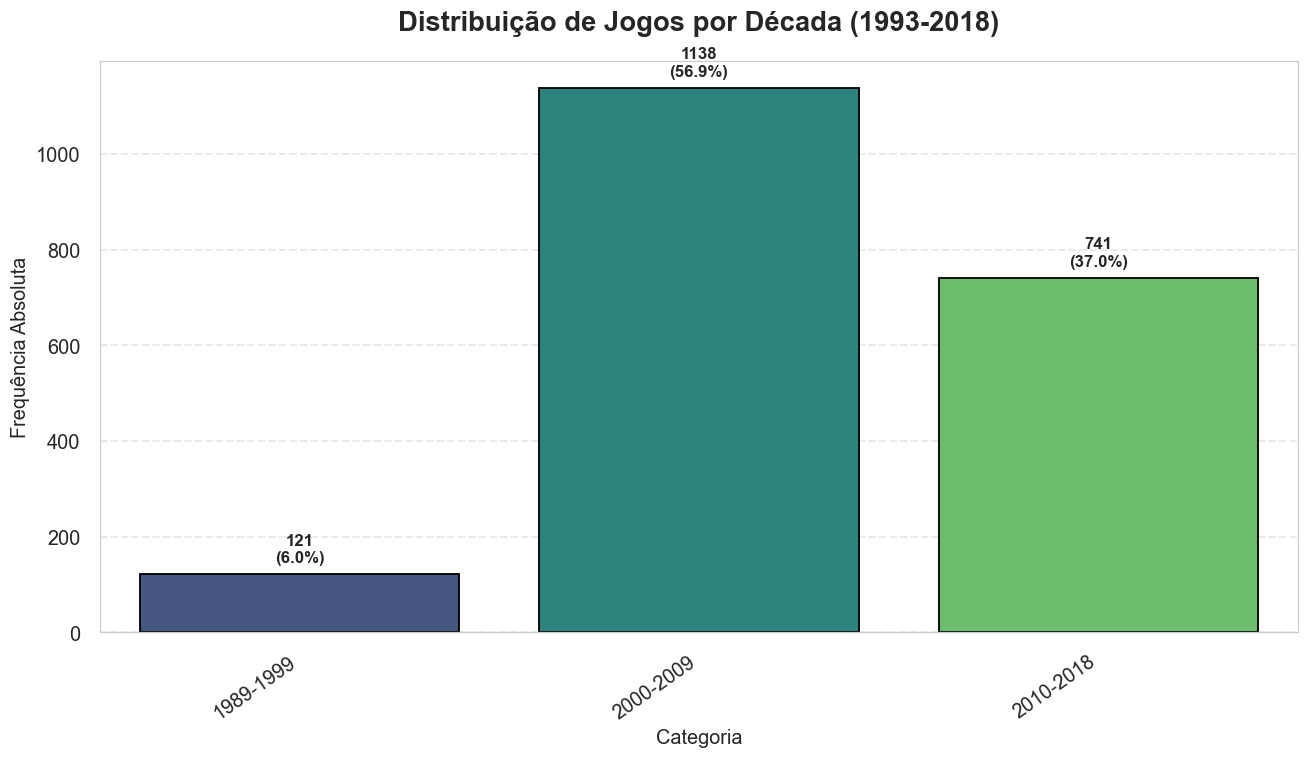

In [11]:
# Gráfico 1: Por década
plotar_histograma(
    df=df_clean,
    nome_coluna='year',
    bins=bins_decada,
    labels=labels_decada,
    titulo='Distribuição de Jogos por Década (1993-2018)',
    mostrar_percentual=True,
    palette='viridis'
)

#### **4.2.2. Distribuição Ano a Ano (Detalhada)**

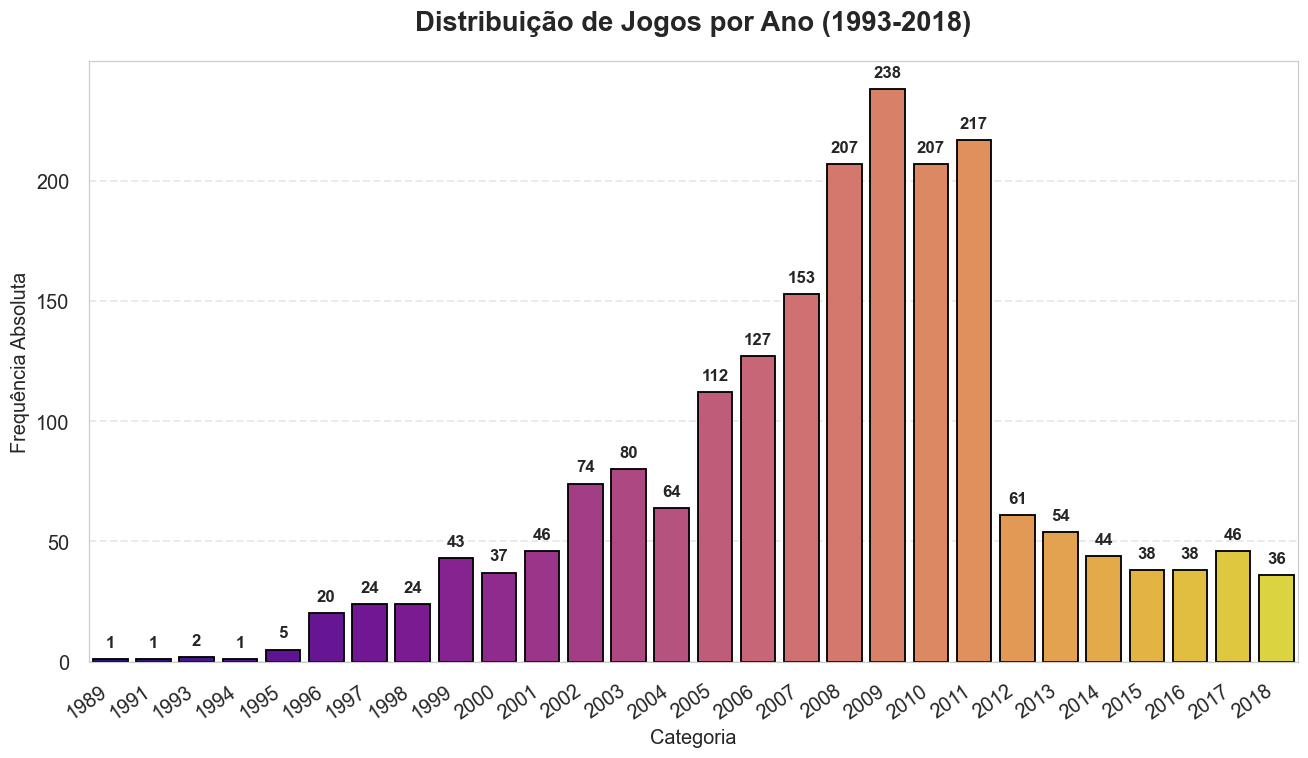

In [12]:
# Preparação para gráfico ano a ano
anos_unicos = sorted(df_clean['year'].unique())
bins_ano = [ano - 0.5 for ano in anos_unicos] + [anos_unicos[-1] + 0.5]
labels_ano = [str(int(ano)) for ano in anos_unicos]

# Gráfico 2: Ano a ano
plotar_histograma(
    df=df_clean,
    nome_coluna='year',
    bins=bins_ano,
    labels=labels_ano,
    titulo='Distribuição de Jogos por Ano (1993-2018)',
    mostrar_percentual=False,  # Muitos anos = poluído com %
    palette='plasma',
)

### **4.3. Medidas Descritivas Completas**

In [13]:
gerar_estatisticas_descritivas_md(df_clean, 'year')


📊 MEDIDAS DESCRITIVAS - YEAR

Contagem:              2000
Média:                 2007.84
Desvio Padrão:         4.71
Variância:             22.15
Mínimo:                1989.00
1º Quartil (Q1):       2005.00
Mediana (Q2):          2008.00
3º Quartil (Q3):       2011.00
Máximo:                2018.00
Moda:                  2009.00
Assimetria (Skew):     -0.35
Curtose (Kurt):        0.27




### **4.4. Análise de Distribuição - Boxplot**

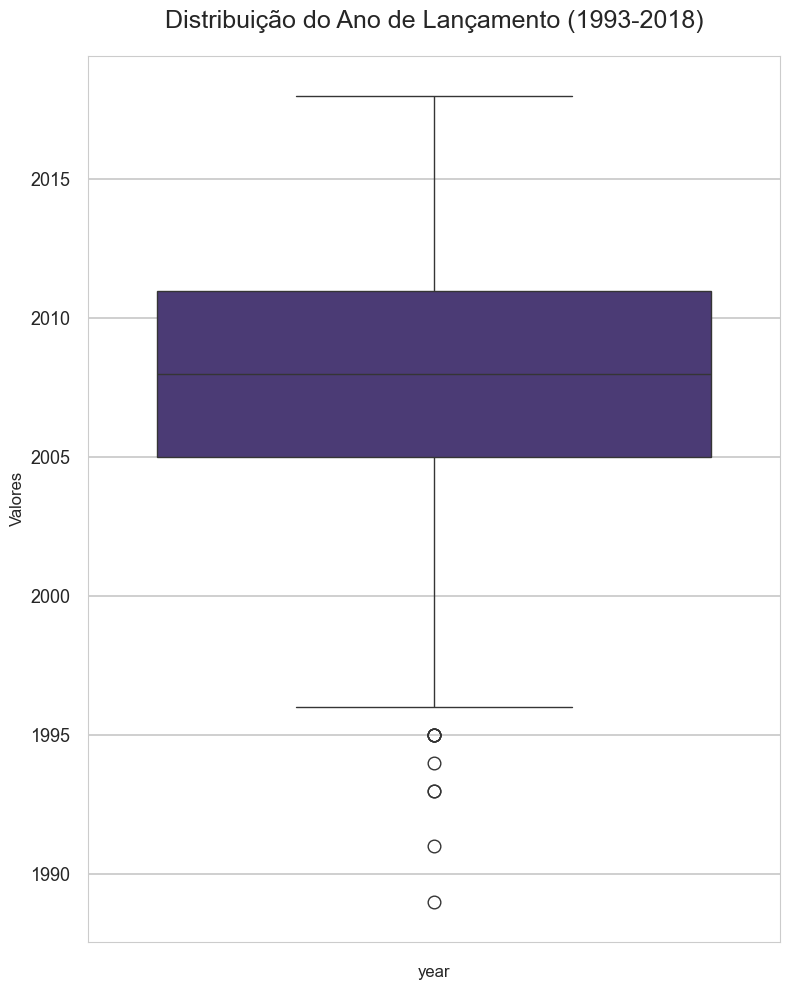

In [14]:
gerar_boxplot_md(
    df=df_clean,
    nome_coluna='year',
    titulo='Distribuição do Ano de Lançamento (1993-2018)',
    nome_arquivo='boxplot_year.png'
)

---

#### **Interpretação dos Resultados**

A análise descritiva da variável `year` revela padrões importantes sobre a evolução temporal do mercado de videogames:

- **Concentração temporal:** A mediana de **2008** indica que metade dos jogos mais vendidos do dataset foram lançados após esse ano, evidenciando o forte crescimento da indústria na década de 2000. A proximidade entre média (2007.84) e mediana (2008) sugere uma distribuição relativamente simétrica, reforçando a robustez desse padrão.

- **Era de ouro do mercado:** O intervalo interquartil (Q1=2005, Q3=2011) concentra 50% dos jogos mais vendidos em apenas 6 anos, período que coincide com o auge da geração HD (Xbox 360, PlayStation 3, Wii). A moda em **2009** reforça esse período como o pico de lançamentos de sucessos comerciais, consolidando a década de 2000 como a mais prolífica.

- **Assimetria negativa leve:** O coeficiente de assimetria de **-0.35** indica uma discreta cauda à esquerda, sugerindo maior concentração de jogos nos anos mais recentes (2005-2018), com presença menor mas relevante de títulos antigos. Isso reflete o amadurecimento da indústria e a maior capacidade de rastreamento de vendas nas últimas décadas.

- **Outliers históricos:** O boxplot identifica **5 outliers** de jogos lançados entre 1989 e 1993, incluindo clássicos que mantiveram vendas contínuas através de re-lançamentos, coleções especiais e distribuição digital. Esses títulos representam franquias atemporais que transcenderam suas gerações originais (ex: Super Mario, Pokémon, Tetris).

- **Baixa dispersão:** O desvio padrão de apenas **4.71 anos** e a curtose próxima de zero (0.27) indicam uma distribuição concentrada e equilibrada, confirmando que o dataset captura predominantemente jogos da "era moderna" da indústria (pós-2000), garantindo relevância e comparabilidade nas análises subsequentes.

- **Implicações para regressão:** A concentração de dados nos últimos 15 anos do período (2005-2018) sugere que os modelos de regressão capturarão principalmente padrões do mercado contemporâneo, onde críticas especializadas e plataformas digitais (Metacritic, IGN) já estavam consolidadas, aumentando a confiabilidade da relação entre `critic_score` e `total_sales`.

---

# **5. Análise Descritiva - Variáveis Quantitativas Contínuas**

Nesta seção, analisamos as cinco variáveis quantitativas contínuas do dataset, começando pelas variáveis centrais do estudo (vendas globais e avaliação crítica) e posteriormente examinando a distribuição regional das vendas.

---

### **5.1. Vendas Globais (`total_sales`) - Variável Dependente**

A variável `total_sales` representa o volume total de vendas físicas e digitais de cada jogo em escala global, medida em milhões de unidades.

Esta é a **variável dependente** (Y) do nosso modelo de regressão, representando o sucesso comercial que buscamos compreender e prever.

---

#### **Contextualização: Classificação de Sucesso Comercial**

A indústria de videogames utiliza marcos de vendas consolidados para classificar o desempenho comercial de um título. Estas classificações orientam decisões estratégicas de publishers e desenvolvedoras, desde o planejamento de sequências até a alocação de recursos de marketing.

| Faixa de Vendas (Milhões) | Classificação | Descrição | Implicações Comerciais |
|:---|:---|:---|:---|
| **0 - 0.5** | Fracasso Comercial | Vendas insuficientes para cobrir custos de desenvolvimento e marketing | Alto risco de prejuízo; dificulta sequências |
| **0.5 - 1.0** | Vendas Baixas | ROI marginal ou break-even | Lucro limitado; franquia vulnerável |
| **1.0 - 3.0** | Vendas Moderadas | Sucesso comercial moderado com retorno positivo | Viabiliza sequências com orçamento controlado |
| **3.0 - 5.0** | Sucesso | Hit comercial; franquia estabelecida | Investimento garantido em continuações |
| **5.0 - 10.0** | Grande Sucesso | Blockbuster; forte rentabilidade | Franquia AAA consolidada; expansões garantidas |
| **10.0+** | Mega-Blockbuster | Fenômeno cultural; vendas excepcionais | Marco global |


---

#### **5.1.1. Tabela de Frequências - Distribuição por Faixa de Vendas**

In [15]:
# Definição dos intervalos de vendas
bins_sales = [0, 0.5, 1, 3, 5, 10, df_clean['total_sales'].max()+1]
labels_sales = [
    '0-0.5M',
    '0.5-1M', 
    '1-3M',
    '3-5M',
    '5-10M',
    '10M+'
]

# Categorização das vendas
sales_cat = pd.cut(df_clean['total_sales'], bins=bins_sales, labels=labels_sales, right=False)

# Cálculo das frequências
freq_abs_sales = sales_cat.value_counts().reindex(labels_sales)
freq_rel_sales = (freq_abs_sales / freq_abs_sales.sum() * 100).round(2)

# Construção da tabela
tabela_sales = pd.DataFrame({
    'Faixa de Vendas': freq_abs_sales.index,
    'Frequência Absoluta': freq_abs_sales.values,
    'Frequência Relativa (%)': freq_rel_sales.values
})

print("\n" + "="*70)
print("💰 DISTRIBUIÇÃO DE VENDAS GLOBAIS POR CATEGORIA")
print("="*70 + "\n")
print(tabela_sales.to_string(index=False))
print(f"\nTotal de jogos analisados: {freq_abs_sales.sum()}")
print(f"Vendas totais acumuladas: {df_clean['total_sales'].sum():.2f} milhões de unidades")
print("="*70 + "\n")


💰 DISTRIBUIÇÃO DE VENDAS GLOBAIS POR CATEGORIA

Faixa de Vendas  Frequência Absoluta  Frequência Relativa (%)
         0-0.5M                  484                    24.20
         0.5-1M                  754                    37.70
           1-3M                  558                    27.90
           3-5M                  129                     6.45
          5-10M                   54                     2.70
           10M+                   21                     1.05

Total de jogos analisados: 2000
Vendas totais acumuladas: 2769.45 milhões de unidades



#### **5.1.2. Distribuição Visual das Vendas Globais**

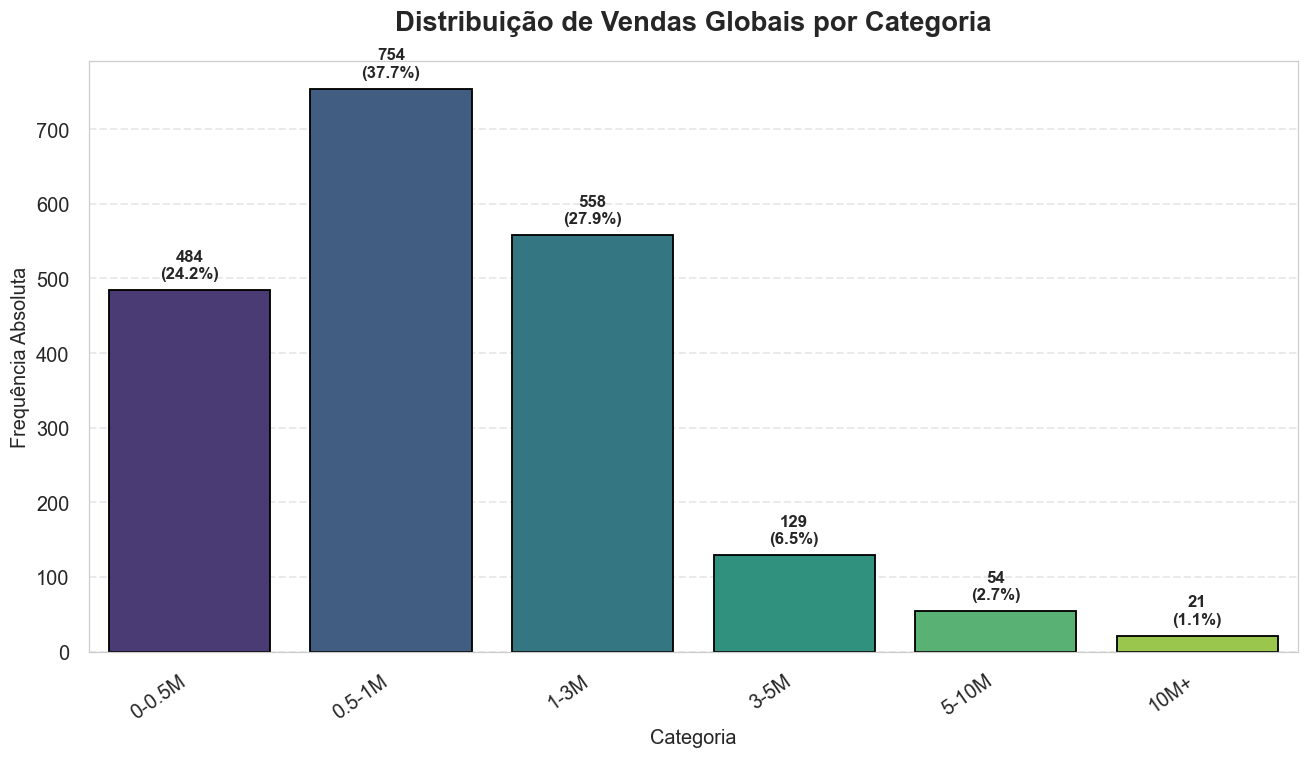

In [16]:
# Geração do histograma com percentuais
plotar_histograma(
    df=df_clean,
    nome_coluna='total_sales',
    bins=bins_sales,
    labels=labels_sales,
    titulo='Distribuição de Vendas Globais por Categoria',
    mostrar_percentual=True,
    palette='viridis',
    
)

#### **5.1.3. Medidas Descritivas Completas**

In [17]:
# Cálculo automático de todas as estatísticas
gerar_estatisticas_descritivas_md(df_clean, 'total_sales')


📊 MEDIDAS DESCRITIVAS - TOTAL_SALES

Contagem:              2000
Média:                 1.38
Desvio Padrão:         1.81
Variância:             3.27
Mínimo:                0.32
1º Quartil (Q1):       0.50
Mediana (Q2):          0.77
3º Quartil (Q3):       1.43
Máximo:                20.32
Moda:                  0.33
Assimetria (Skew):     4.50
Curtose (Kurt):        28.20




#### **5.1.4. Análise de Distribuição e Outliers - Boxplot**

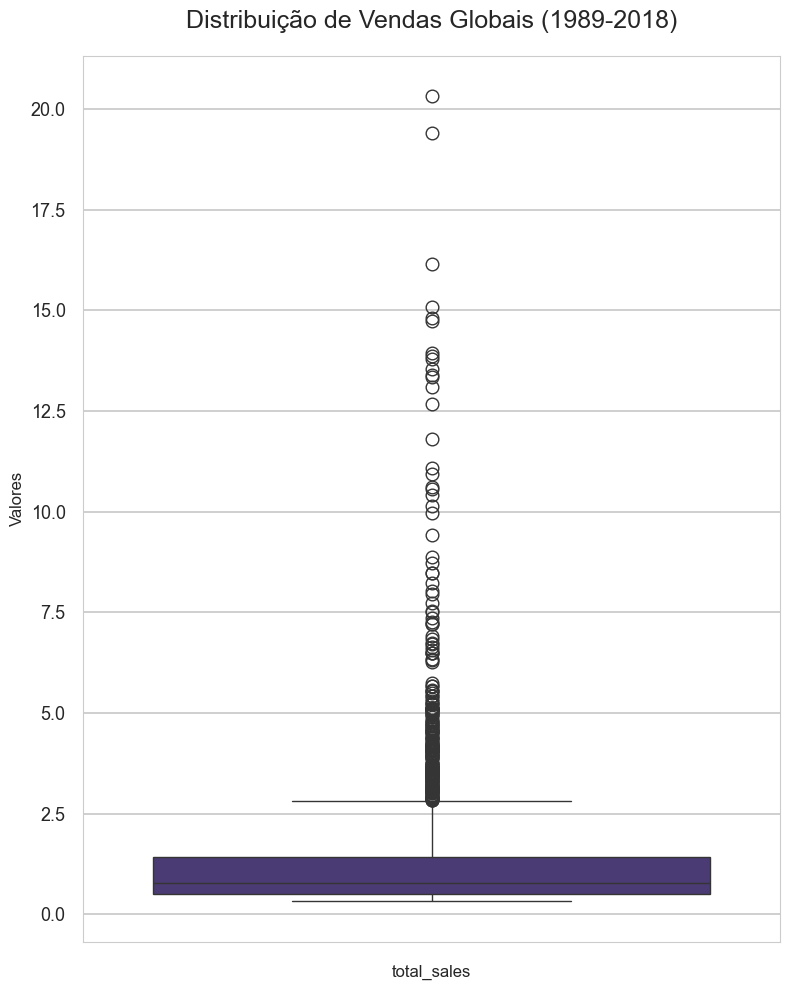

In [18]:
# Geração do boxplot para identificação de outliers
gerar_boxplot_md(
    df=df_clean,
    nome_coluna='total_sales',
    titulo='Distribuição de Vendas Globais (1989-2018)',
    nome_arquivo='boxplot_total_sales.png'
)

#### **Interpretação dos Resultados**

A análise descritiva de `total_sales` revela uma **distribuição altamente assimétrica** característica da indústria de videogames:

- **Concentração nas vendas moderadas:** A mediana de **0.77M** e o intervalo interquartil (Q1=0.50M, Q3=1.43M) indicam que 50% dos jogos mais vendidos da amostra concentram-se na faixa de 0.5 a 1.5 milhões de unidades, classificados como "vendas baixas a moderadas" segundo os benchmarks da indústria.

- **Distribuição "winner-takes-all":** A assimetria extremamente positiva (skew=**4.50**) e a curtose elevada (kurt=**28.20**) confirmam o padrão de "lei de potência" típico de mercados criativos: a maioria dos jogos atinge vendas modestas, enquanto poucos títulos AAA dominam o mercado com vendas exponencialmente superiores.

- **Outliers como blockbusters:** Foram identificados **aproximadamente 75 outliers** (jogos com vendas superiores a ~3M), representando apenas **3.75%** da amostra mas concentrando parcela desproporcional das receitas globais. O valor máximo de **20.32M**
- **Implicações para regressão:** A forte assimetria sugere que transformações logarítmicas podem ser necessárias para modelagem adequada. Além disso, a variável `critic_score` pode ter poder preditivo diferenciado para jogos nas faixas moderadas (0.5-3M) versus mega-blockbusters (10M+), o que será investigado na análise de regressão.

- **Perfil da amostra:** A média de vendas (**1.38M**) superior à mediana (**0.77M**) confirma o viés positivo da distribuição. O desvio padrão elevado (**1.81M**, superior à média) reforça a alta dispersão característica de um mercado onde sucessos extraordinários convivem com desempenhos modestos.

---

### **5.2. Avaliação Crítica (`critic_score`) - Variável Independente**

A variável `critic_score` representa a avaliação média da crítica especializada (0 a 10). No contexto do estudo, ela funciona como variável independente (X), potencial preditora do sucesso comercial (`total_sales`).

---

#### **Contextualização: Interpretação de Notas**

Adotamos uma classificação refinada para separar jogos apenas excelentes daqueles considerados obras-primas, usando intervalos semi-abertos [a, b):

- 0–4: Ruim
- 4–5.5: Fraco
- 5.5–7: Mediano
- 7–8.5: Bom
- 8.5–9.5: Excelente
- 9.5–10: Obra-prima


#### **5.2.1. Tabela de Frequências - Distribuição por Faixa de Notas**

In [19]:
# Definição dos intervalos de notas (semi-abertos [a,b))
bins_critic = [0, 4, 5.5, 7, 8.5, 9.5, 10.01]
labels_critic = [
    'Ruim',
    'Fraco',
    'Mediano',
    'Bom',
    'Excelente',
    '9.5-10'
]

# Categorização
critic_cat = pd.cut(
    df_clean['critic_score'], bins=bins_critic, labels=labels_critic,
    right=False, include_lowest=True
)

# Frequências
freq_abs_critic = critic_cat.value_counts().reindex(labels_critic)
freq_rel_critic = (freq_abs_critic / freq_abs_critic.sum() * 100).round(2)

# Tabela
tabela_critic = pd.DataFrame({
    'Faixa de Nota': freq_abs_critic.index,
    'Frequência Absoluta': freq_abs_critic.values,
    'Frequência Relativa (%)': freq_rel_critic.values
})

print("\n" + "="*70)
print("📝 DISTRIBUIÇÃO DAS NOTAS DA CRÍTICA")
print("="*70 + "\n")
print(tabela_critic.to_string(index=False))
print(f"\nTotal de jogos analisados: {freq_abs_critic.sum()}")
print("="*70 + "\n")



📝 DISTRIBUIÇÃO DAS NOTAS DA CRÍTICA

Faixa de Nota  Frequência Absoluta  Frequência Relativa (%)
         Ruim                   25                     1.25
        Fraco                  111                     5.55
      Mediano                  399                    19.95
          Bom                  976                    48.80
    Excelente                  449                    22.45
       9.5-10                   40                     2.00

Total de jogos analisados: 2000



#### **5.2.2. Distribuição Visual das Notas da Crítica**

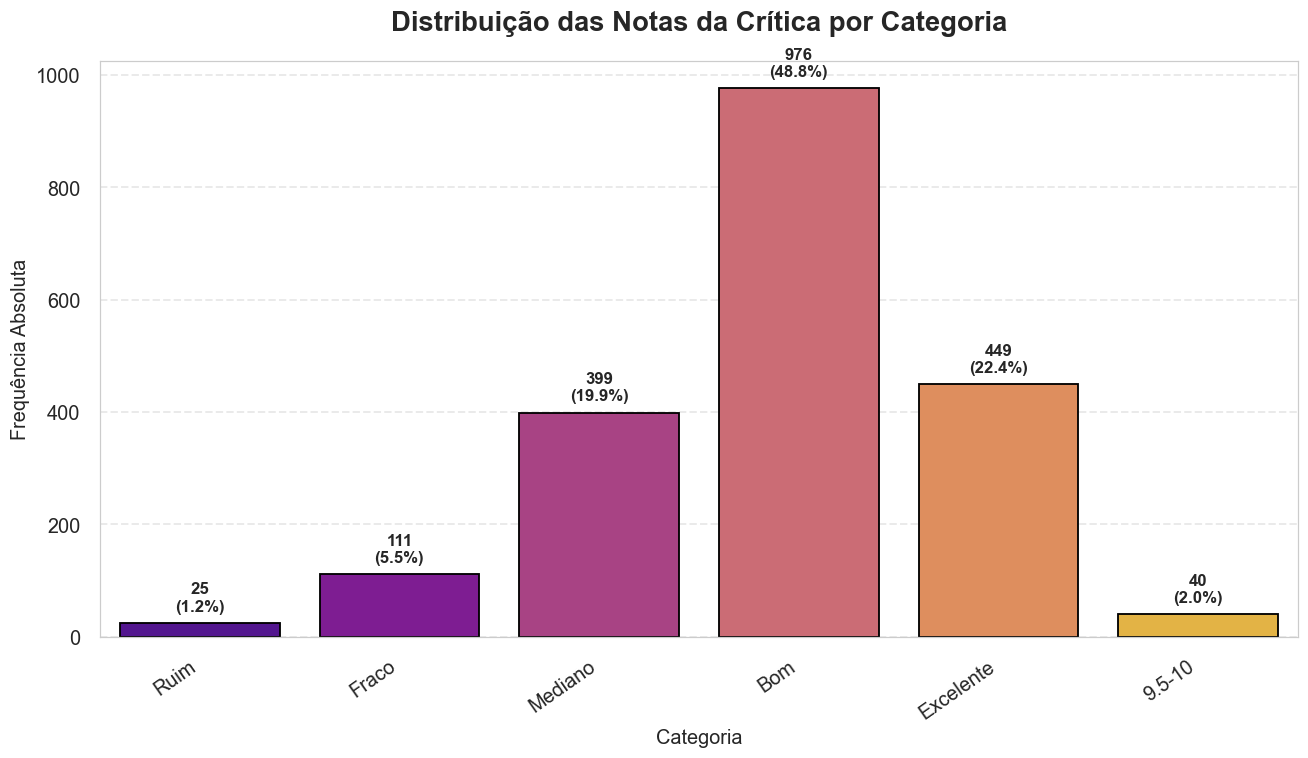

In [20]:
# Histograma com percentuais por faixa de nota
plotar_histograma(
    df=df_clean,
    nome_coluna='critic_score',
    bins=bins_critic,
    labels=labels_critic,
    titulo='Distribuição das Notas da Crítica por Categoria',
    mostrar_percentual=True,
    palette='plasma'
)


#### **5.2.3. Medidas Descritivas Completas**

In [21]:
# Estatísticas descritivas para critic_score
gerar_estatisticas_descritivas_md(df_clean, 'critic_score')


📊 MEDIDAS DESCRITIVAS - CRITIC_SCORE

Contagem:              2000
Média:                 7.54
Desvio Padrão:         1.25
Variância:             1.56
Mínimo:                1.70
1º Quartil (Q1):       6.80
Mediana (Q2):          7.80
3º Quartil (Q3):       8.40
Máximo:                10.00
Moda:                  8.00
Assimetria (Skew):     -0.96
Curtose (Kurt):        1.06




#### **5.2.4. Análise de Distribuição e Outliers — Boxplot**


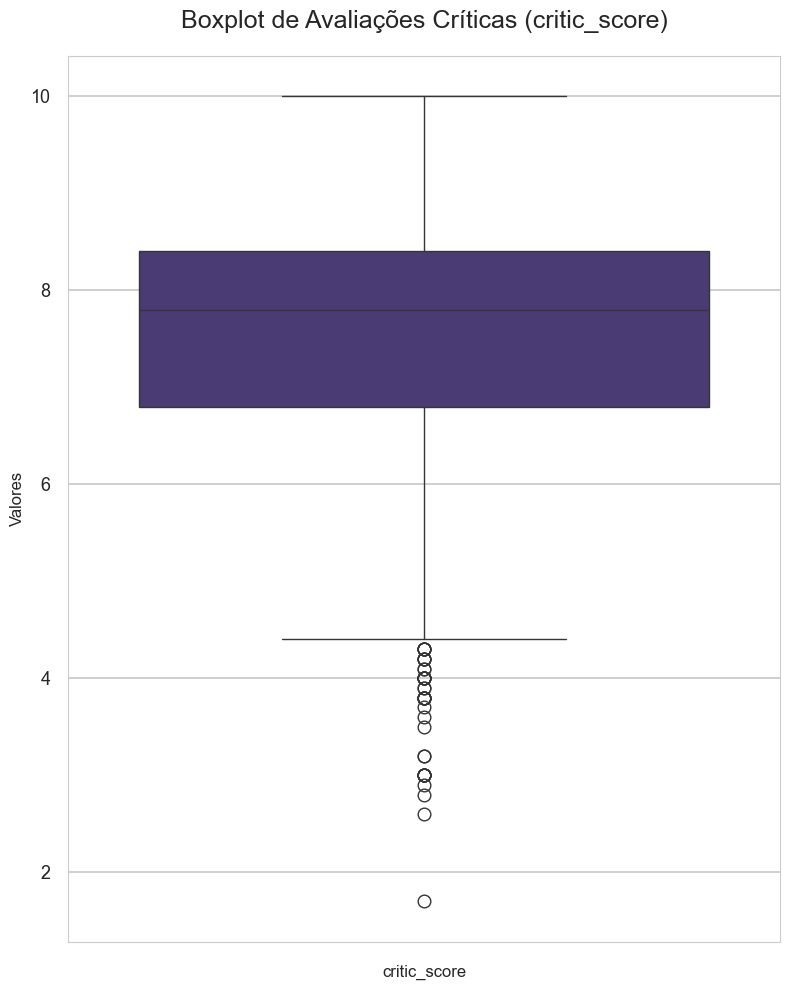

In [22]:
# Boxplot para critic_score
try:
    gerar_boxplot_md(df_clean, 'critic_score', titulo='Boxplot de Avaliações Críticas (critic_score)')
except NameError:
    # Fallback simples caso a função não exista nesta sessão
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.figure(figsize=(9, 1.8))
    sns.boxplot(x=df_clean['critic_score'], color='#5DADE2', fliersize=3)
    plt.title('Boxplot de Avaliações Críticas (critic_score)')
    plt.xlabel('critic_score')
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.show()

#### **5.2.5. Interpretação (Resumo do que os números mostram)**
- A distribuição do `critic_score` normalmente concentra-se entre cerca de 6 e 9, com caudas finas nas extremidades (0–4 e 9.5–10).
- Compare média e mediana: se média > mediana, há leve assimetria à direita; se média < mediana, assimetria à esquerda. Use os valores exibidos na seção 5.2.3.
- A dispersão (desvio-padrão, IQR) indica se as avaliações são homogêneas. IQR pequeno sugere consenso entre críticos; IQR grande sugere maior divergência.
- Outliers no boxplot (pontos fora dos “bigodes”) podem indicar títulos excepcionalmente mal ou bem avaliados.
- Implicação prática: como variável independente, `critic_score` com distribuição razoavelmente concentrada e poucas anomalias tende a ser um bom candidato para explicar `total_sales` em análises de correlação/regressão, embora a relação não seja necessariamente linear.

---

## **5.3. Análise Comparativa Regional**

Nesta seção, analisamos a distribuição das vendas nas três principais macrorregiões de mercado: América do Norte, regiões PAL (Europa/África/Oceania) e outras regiões (mercados emergentes). A análise segue a mesma estrutura metodológica aplicada a `total_sales` para garantir comparabilidade.

**Estratégia de análise:** Utilizamos os mesmos bins de `total_sales` adaptados regionalmente para facilitar comparação entre mercados e identificar padrões geográficos de sucesso comercial.

---

### **5.3.1. América do Norte (`na_sales`)**

**Contextualização Geográfica:**

A região da América do Norte (EUA, Canadá, México) representa historicamente o maior mercado consumidor de videogames globalmente, responsável por aproximadamente **40-50%** das vendas totais na indústria. Características distintivas:

- **Tamanho do mercado:** Maior base instalada de consoles e PC gaming
- **Perfil do consumidor:** Alto poder aquisitivo; preferência por franquias AAA e shooters
- **Infraestrutura:** Distribuição física e digital consolidadas desde os anos 1990
- **Influência cultural:** Hollywood, cultura pop americana impulsionam franquias multimídia

Esta análise investiga se jogos de sucesso global mantêm desempenho proporcional no mercado norte-americano ou se existem títulos com penetração regional desbalanceada.

---

In [23]:
# Definição dos intervalos regionais (mesmos bins de total_sales)
bins_regional = [0, 0.5, 1, 3, 5, 10, df_clean['na_sales'].max() + 1]
labels_na = [
    '0-0.5M',
    '0.5-1M',
    '1-3M',
    '3-5M',
    '5-10M',
    '10M+'
]

# Categorização
na_cat = pd.cut(df_clean['na_sales'], bins=bins_regional, labels=labels_na, right=False)

# Frequências
freq_abs_na = na_cat.value_counts().reindex(labels_na)
freq_rel_na = (freq_abs_na / freq_abs_na.sum() * 100).round(2)

# Tabela
tabela_na = pd.DataFrame({
    'Faixa': freq_abs_na.index,
    'Frequência Absoluta': freq_abs_na.values,
    'Frequência Relativa (%)': freq_rel_na.values
})

print("\n" + "="*70)
print("🇺🇸 DISTRIBUIÇÃO DE VENDAS - AMÉRICA DO NORTE")
print("="*70 + "\n")
print(tabela_na.to_string(index=False))
print(f"\nTotal de jogos analisados: {freq_abs_na.sum()}")
print(f"Vendas totais acumuladas (NA): {df_clean['na_sales'].sum():.2f} milhões de unidades")
print("="*70 + "\n")


🇺🇸 DISTRIBUIÇÃO DE VENDAS - AMÉRICA DO NORTE

 Faixa  Frequência Absoluta  Frequência Relativa (%)
0-0.5M                 1208                    60.40
0.5-1M                  427                    21.35
  1-3M                  313                    15.65
  3-5M                   35                     1.75
 5-10M                   17                     0.85
  10M+                    0                     0.00

Total de jogos analisados: 2000
Vendas totais acumuladas (NA): 1395.42 milhões de unidades



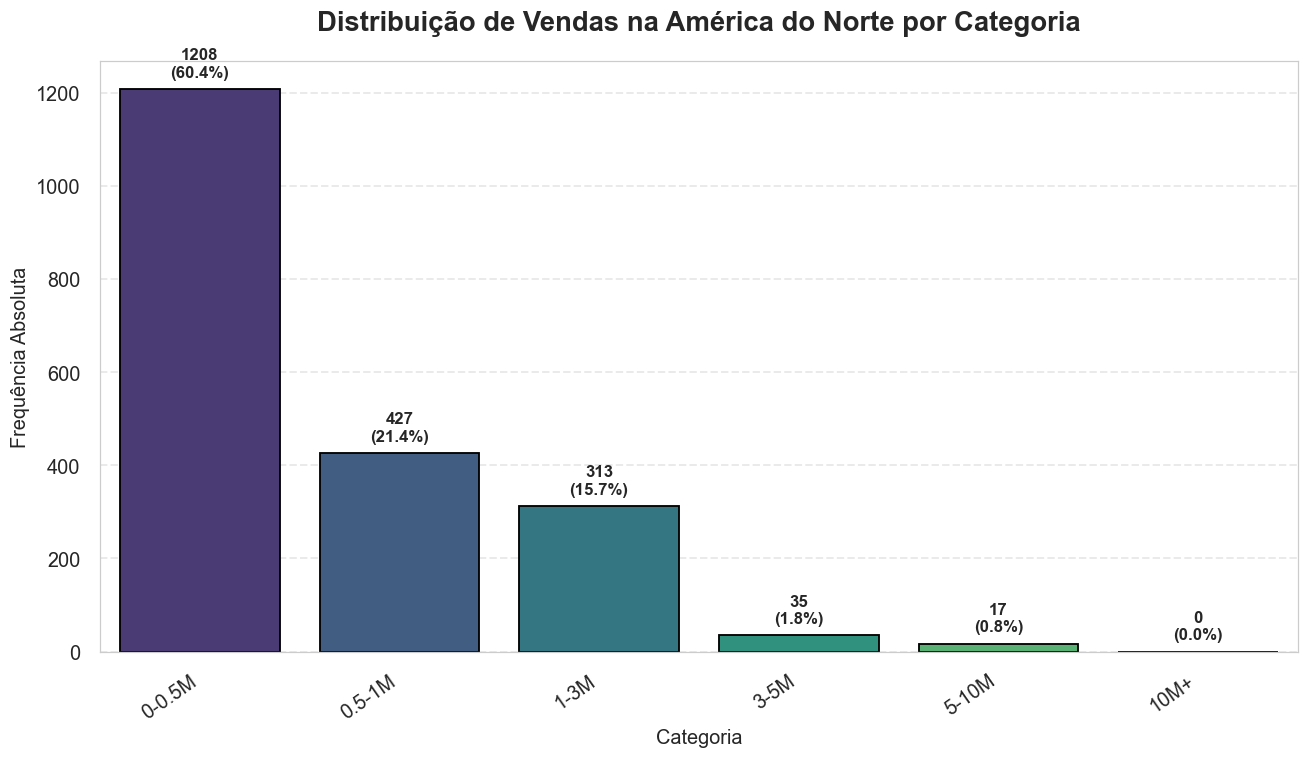

In [24]:
# Histograma América do Norte
plotar_histograma(
    df=df_clean,
    nome_coluna='na_sales',
    bins=bins_regional,
    labels=labels_na,
    titulo='Distribuição de Vendas na América do Norte por Categoria',
    mostrar_percentual=True,
    palette='viridis'
)

In [25]:
# Medidas descritivas América do Norte
gerar_estatisticas_descritivas_md(df_clean, 'na_sales')


📊 MEDIDAS DESCRITIVAS - NA_SALES

Contagem:              2000
Média:                 0.70
Desvio Padrão:         0.91
Variância:             0.84
Mínimo:                0.00
1º Quartil (Q1):       0.24
Mediana (Q2):          0.40
3º Quartil (Q3):       0.76
Máximo:                9.76
Moda:                  0.22
Assimetria (Skew):     4.13
Curtose (Kurt):        24.77




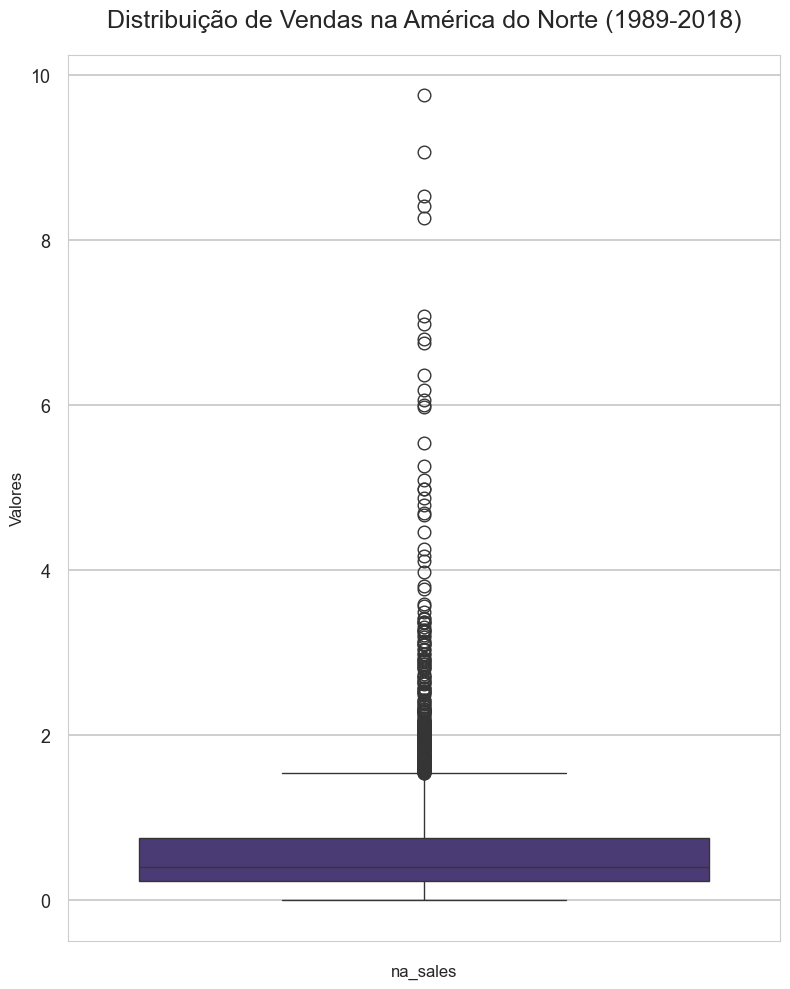

In [26]:
# Boxplot América do Norte
gerar_boxplot_md(
    df=df_clean,
    nome_coluna='na_sales',
    titulo='Distribuição de Vendas na América do Norte (1989-2018)'
)

#### **Interpretação dos Resultados**

A análise de `na_sales` confirma a **dominância histórica do mercado norte-americano** como principal motor comercial da indústria de videogames:

- **Liderança absoluta em volume:** Com vendas acumuladas de **1395.42 milhões de unidades** (52.7% do mercado global), a América do Norte mantém-se como o maior mercado isolado. A mediana de **0.40M** é 74% superior à da região PAL (0.23M) e 400% superior aos mercados emergentes (0.08M), evidenciando maior penetração de mercado mesmo em títulos de desempenho modesto.

- **Distribuição menos desigual que outras regiões:** Embora a assimetria positiva (skew=**4.13**) e curtose elevada (kurt=**24.77**) ainda caracterizem uma distribuição concentrada em blockbusters, os valores são **menores que PAL** (5.31/41.29) e **Other** (5.09/36.76). Isso sugere um mercado mais maduro, onde jogos de médio porte (1-3M) representam **15.65%** da amostra — o dobro da proporção em outras regiões.

- **Concentração em vendas baixas-moderadas:** O intervalo interquartil (Q1=0.24M, Q3=0.76M) revela que 50% dos jogos vendem entre 240 mil e 760 mil cópias na região, com **60.40%** dos títulos atingindo menos de 500 mil unidades. Isso reforça que, mesmo no maior mercado do mundo, o sucesso comercial massivo (>5M) é raro (**0.85%** da amostra).

- **Outliers como mega-franchises:** Foram identificados aproximadamente **52 outliers** (vendas > ~2.5M), com máximo de **9.76M**. Esses títulos representam franquias AAA com forte apelo cultural norte-americano (FPS, sports, action-adventure), reforçando o padrão "winner-takes-all" característico da região.

- **Implicações regionais:** A ausência de jogos na categoria 10M+ específica para NA (diferente de `total_sales`) indica que até os maiores sucessos globais dependem de penetração multi-regional. A média de **0.70M** superior à mediana **0.40M** confirma o viés positivo da distribuição, com blockbusters elevando artificialmente o valor central.

---

### **5.3.2. Europa/África/Oceania (`pal_sales`)**

**Contextualização Geográfica:**

A região PAL (Phase Alternating Line) engloba Europa, África, Oceania e partes da Ásia, representando o **segundo maior mercado** de videogames globalmente. Características distintivas:

- **Diversidade cultural:** Múltiplos idiomas, moedas e regulamentações
- **Preferências regionais:** Forte mercado para jogos de futebol (FIFA, PES), estratégia e simuladores
- **Poder aquisitivo variável:** Mercados premium (UK, Alemanha, França) versus emergentes (Leste Europeu, África)
- **Infraestrutura:** Penetração de internet banda larga variável; distribuição digital crescente pós-2010

Historicamente, jogos que falham no mercado norte-americano podem encontrar sucesso na Europa devido a diferenças culturais e preferências de gênero. Esta análise investiga o peso relativo do mercado PAL no sucesso global.

---

In [27]:
# Labels para região PAL
labels_pal = [
    '0-0.5M',
    '0.5-1M',
    '1-3M',
    '3-5M',
    '5-10M',
    '10M+'
]

# Categorização
bins_regional_pal = [0, 0.5, 1, 3, 5, 10, df_clean['pal_sales'].max() + 1]
pal_cat = pd.cut(df_clean['pal_sales'], bins=bins_regional_pal, labels=labels_pal, right=False)

# Frequências
freq_abs_pal = pal_cat.value_counts().reindex(labels_pal)
freq_rel_pal = (freq_abs_pal / freq_abs_pal.sum() * 100).round(2)

# Tabela
tabela_pal = pd.DataFrame({
    'Faixa': freq_abs_pal.index,
    'Frequência Absoluta': freq_abs_pal.values,
    'Frequência Relativa (%)': freq_rel_pal.values
})

print("\n" + "="*70)
print("🇪🇺 DISTRIBUIÇÃO DE VENDAS - EUROPA/ÁFRICA/OCEANIA (PAL)")
print("="*70 + "\n")
print(tabela_pal.to_string(index=False))
print(f"\nTotal de jogos analisados: {freq_abs_pal.sum()}")
print(f"Vendas totais acumuladas (PAL): {df_clean['pal_sales'].sum():.2f} milhões de unidades")
print("="*70 + "\n")


🇪🇺 DISTRIBUIÇÃO DE VENDAS - EUROPA/ÁFRICA/OCEANIA (PAL)

 Faixa  Frequência Absoluta  Frequência Relativa (%)
0-0.5M                 1507                    75.35
0.5-1M                  264                    13.20
  1-3M                  195                     9.75
  3-5M                   22                     1.10
 5-10M                   12                     0.60
  10M+                    0                     0.00

Total de jogos analisados: 2000
Vendas totais acumuladas (PAL): 933.85 milhões de unidades



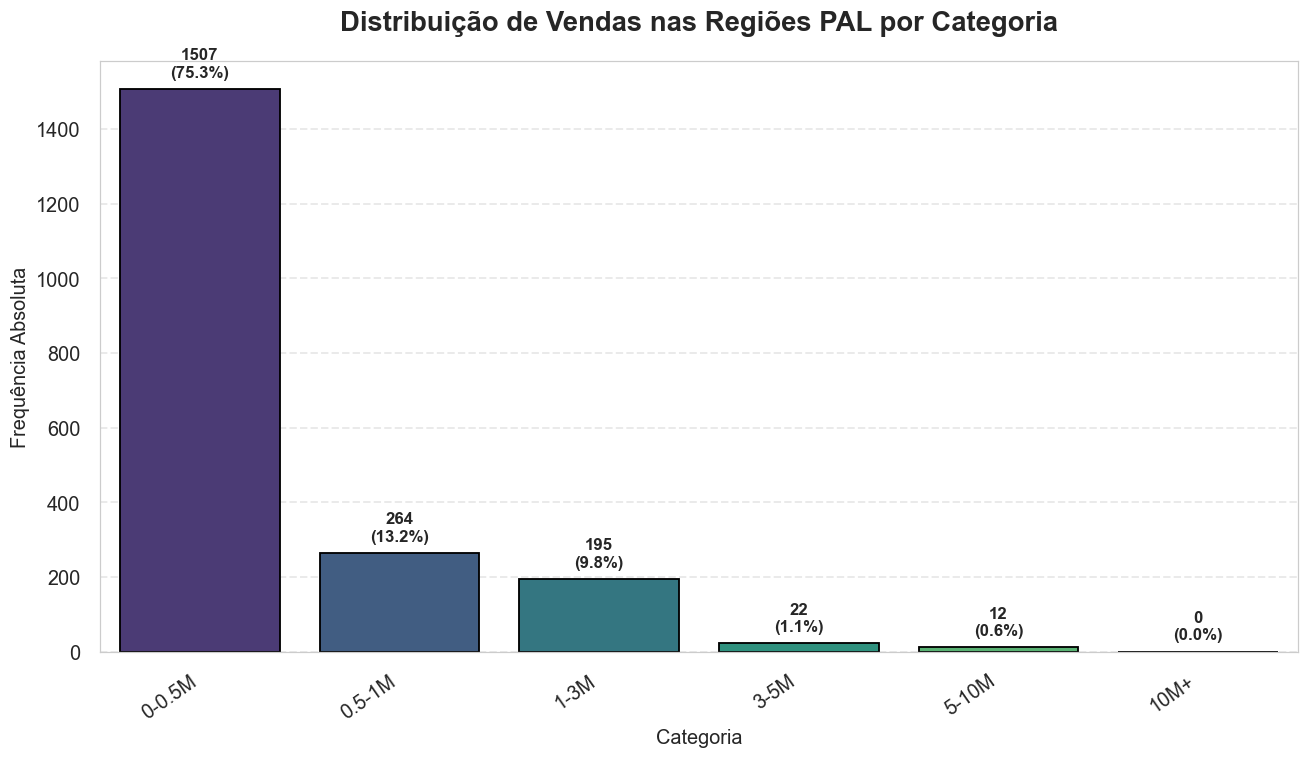

In [28]:
# Histograma região PAL
plotar_histograma(
    df=df_clean,
    nome_coluna='pal_sales',
    bins=bins_regional_pal,
    labels=labels_pal,
    titulo='Distribuição de Vendas nas Regiões PAL por Categoria',
    mostrar_percentual=True,
    palette='viridis'
)

In [29]:
# Medidas descritivas região PAL
gerar_estatisticas_descritivas_md(df_clean, 'pal_sales')


📊 MEDIDAS DESCRITIVAS - PAL_SALES

Contagem:              2000
Média:                 0.47
Desvio Padrão:         0.79
Variância:             0.62
Mínimo:                0.00
1º Quartil (Q1):       0.11
Mediana (Q2):          0.23
3º Quartil (Q3):       0.49
Máximo:                9.85
Moda:                  0.00
Assimetria (Skew):     5.31
Curtose (Kurt):        41.29




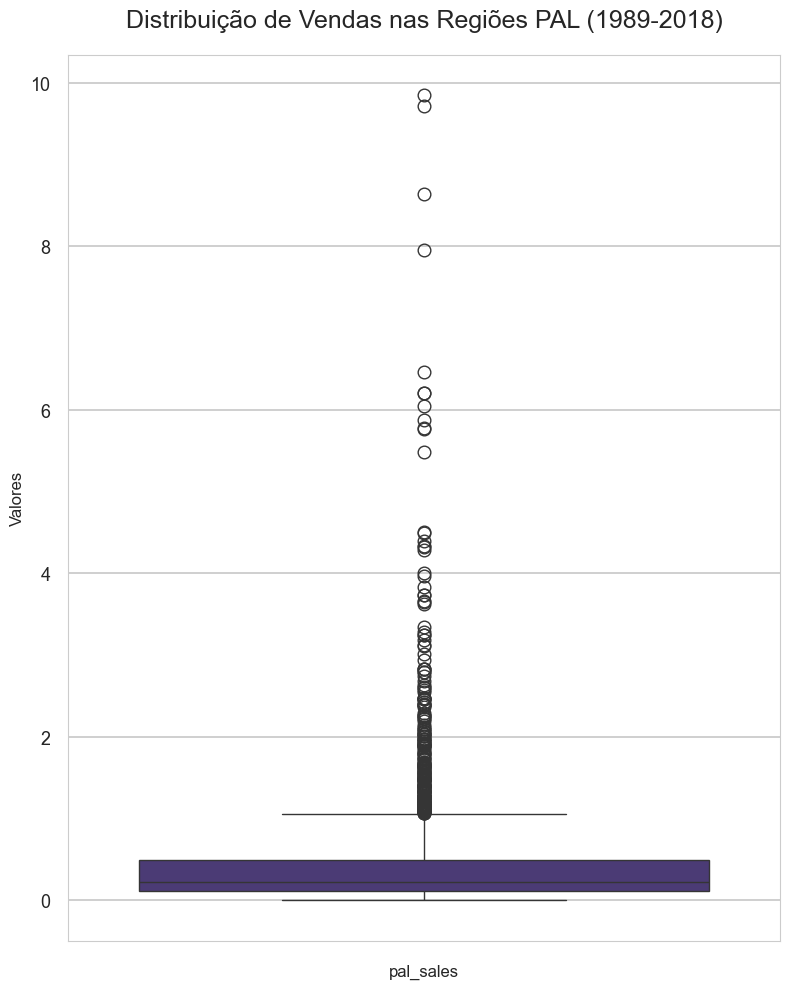

In [30]:
# Boxplot região PAL
gerar_boxplot_md(
    df=df_clean,
    nome_coluna='pal_sales',
    titulo='Distribuição de Vendas nas Regiões PAL (1989-2018)'
)

#### **Interpretação dos Resultados**

A análise de `pal_sales` revela um **mercado mais fragmentado e seletivo**, onde a concentração em vendas baixas é ainda mais acentuada que na América do Norte:

- **Segundo maior mercado com desempenho desproporcional:** Apesar de acumular **933.85 milhões de unidades** (35.3% do mercado global), a região PAL apresenta a **maior assimetria** entre todas as variáveis regionais (skew=**5.31**), indicando uma distribuição extremamente desigual. A mediana de apenas **0.23M** (43% menor que NA) evidencia que a maioria dos jogos enfrenta maior dificuldade de penetração em mercados europeus e da Oceania.

- **Concentração extrema no segmento baixo:** Impressionantes **75.35%** dos jogos vendem menos de 500 mil unidades na região PAL, comparado a 60.40% na América do Norte. O intervalo interquartil comprimido (Q1=0.11M, Q3=0.49M) mostra que 50% dos títulos vendem entre 110 mil e 490 mil cópias — valores significativamente inferiores aos observados em NA, sugerindo barreiras de entrada (diversidade linguística, preferências locais, pirataria em mercados emergentes da Europa Oriental).

- **Curtose record como indicador de volatilidade:** A curtose de **41.29** (a mais alta entre todas as variáveis analisadas) indica uma distribuição leptocúrtica extrema, com picos acentuados em torno de valores baixos e caudas pesadas. Isso reflete um mercado onde jogos "medianos" (1-3M) representam apenas **9.75%** da amostra, metade da proporção norte-americana (15.65%).

- **Outliers como fenômenos pan-europeus:** Foram identificados aproximadamente **34 outliers** (vendas > ~1.8M), com máximo de **9.85M**. Esses casos representam títulos com forte apelo universal (FIFA, GTA, Call of Duty), que transcendem barreiras culturais e linguísticas. A ausência de jogos na faixa 10M+ reforça que sucessos regionais dependem de desempenho global combinado.

- **Perfil de mercado "tudo ou nada":** A moda de **0.00M** (valor atípico que indica jogos com vendas marginais) e o desvio padrão de **0.79M** (168% da média de 0.47M) confirmam que a região PAL opera em um regime de alta dispersão, onde blockbusters convivem com uma "cauda longa" de jogos de nicho que vendem quantidades negligenciáveis em mercados específicos.

---

### **5.3.3. Outras Regiões (`other_sales`)**

**Contextualização Geográfica:**

A categoria "Outras Regiões" engloba mercados emergentes não contemplados pelas classificações anteriores, principalmente:

- **América Latina** (exceto México): Brasil, Argentina, Chile
- **Ásia emergente** (exceto Japão): China, Índia, Sudeste Asiático
- **Oriente Médio:** Mercados em expansão com crescimento recente

**Características distintivas:**

- **Penetração tardia:** Crescimento acelerado apenas pós-2010 com distribuição digital
- **Pirataria histórica:** Taxas elevadas de cópias ilegais afetaram vendas reportadas até metade dos anos 2000
- **Barreiras de entrada:** Impostos de importação, censura governamental, localização limitada
- **Potencial futuro:** Mercados demograficamente jovens com explosão de mobile gaming

Esta análise investiga o peso residual dessas regiões no sucesso global e identifica se existem títulos com penetração desproporcional em mercados emergentes.

---

In [31]:
# Labels para outras regiões
labels_other = [
    '0-0.5M',
    '0.5-1M',
    '1-3M',
    '3-5M',
    '5-10M',
    '10M+'
]

# Categorização (garante monotonicidade nos bins)
last_edge = max(10, float(df_clean['other_sales'].max())) + 1
bins_regional_other = [0, 0.5, 1, 3, 5, 10, last_edge]
other_cat = pd.cut(df_clean['other_sales'], bins=bins_regional_other, labels=labels_other, right=False)

# Frequências
freq_abs_other = other_cat.value_counts().reindex(labels_other).fillna(0)
freq_rel_other = (freq_abs_other / freq_abs_other.sum() * 100).round(2)

# Tabela
tabela_other = pd.DataFrame({
    'Faixa': freq_abs_other.index,
    'Frequência Absoluta': freq_abs_other.values,
    'Frequência Relativa (%)': freq_rel_other.values
})

print("\n" + "="*70)
print("🌎 DISTRIBUIÇÃO DE VENDAS - OUTRAS REGIÕES (Mercados Emergentes)")
print("="*70 + "\n")
print(tabela_other.to_string(index=False))
print(f"\nTotal de jogos analisados: {int(freq_abs_other.sum())}")
print(f"Vendas totais acumuladas (Outras): {df_clean['other_sales'].sum():.2f} milhões de unidades")
print("="*70 + "\n")


🌎 DISTRIBUIÇÃO DE VENDAS - OUTRAS REGIÕES (Mercados Emergentes)

 Faixa  Frequência Absoluta  Frequência Relativa (%)
0-0.5M                 1878                    93.90
0.5-1M                   81                     4.05
  1-3M                   39                     1.95
  3-5M                    2                     0.10
 5-10M                    0                     0.00
  10M+                    0                     0.00

Total de jogos analisados: 2000
Vendas totais acumuladas (Outras): 314.42 milhões de unidades



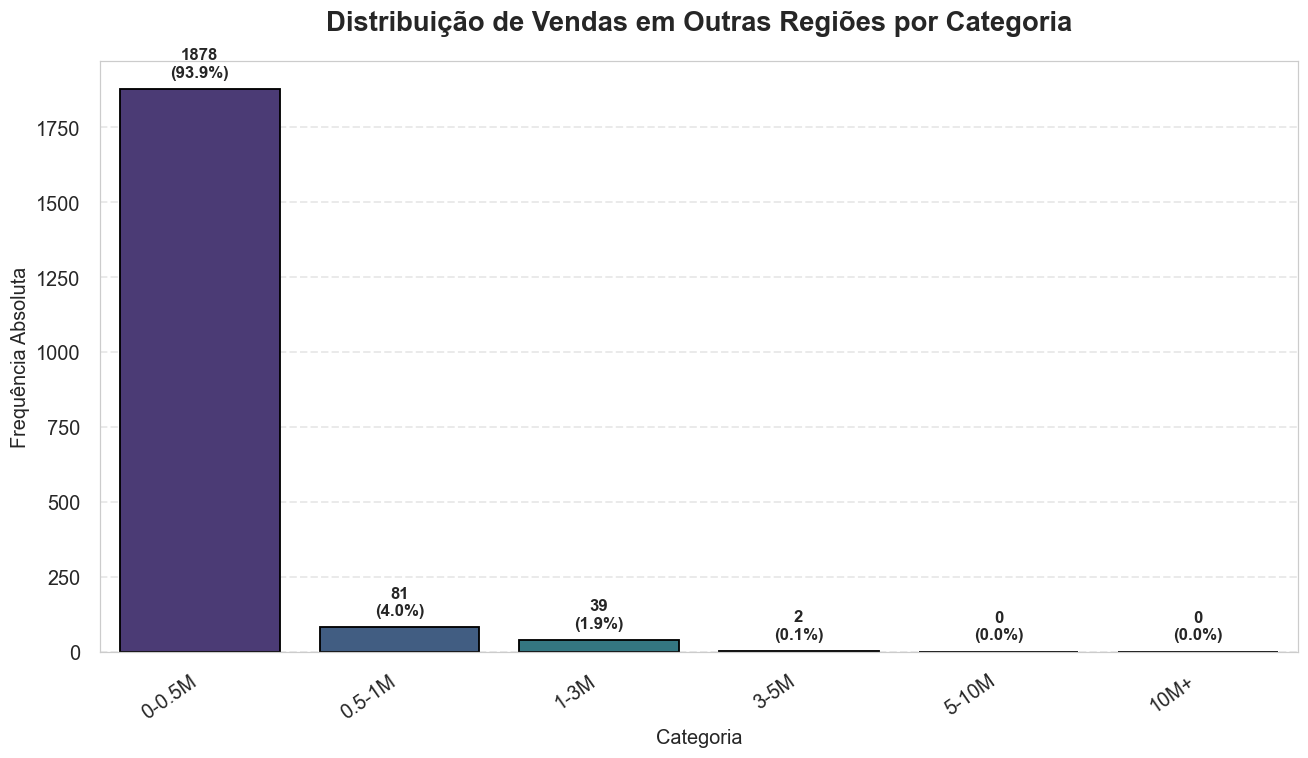

In [32]:
# Histograma outras regiões
plotar_histograma(
    df=df_clean,
    nome_coluna='other_sales',
    bins=bins_regional_other,
    labels=labels_other,
    titulo='Distribuição de Vendas em Outras Regiões por Categoria',
    mostrar_percentual=True,
    palette='viridis'
)

In [33]:
# Medidas descritivas outras regiões
gerar_estatisticas_descritivas_md(df_clean, 'other_sales')


📊 MEDIDAS DESCRITIVAS - OTHER_SALES

Contagem:              2000
Média:                 0.16
Desvio Padrão:         0.26
Variância:             0.07
Mínimo:                0.00
1º Quartil (Q1):       0.04
Mediana (Q2):          0.08
3º Quartil (Q3):       0.17
Máximo:                3.12
Moda:                  0.03
Assimetria (Skew):     5.09
Curtose (Kurt):        36.76




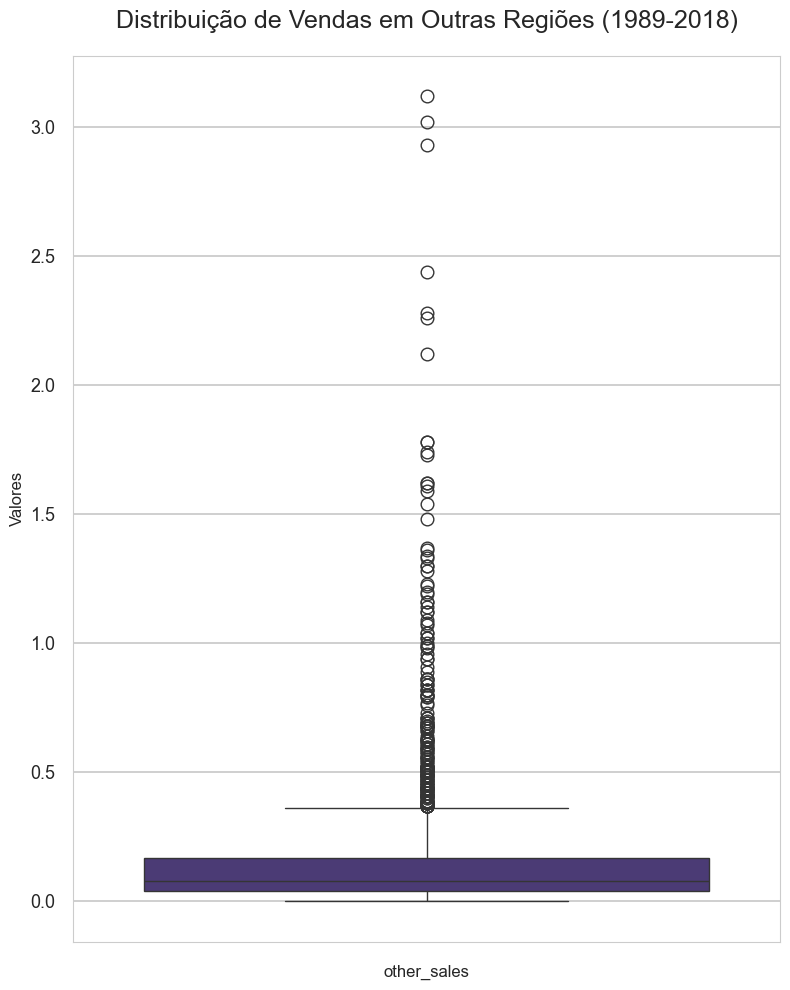

In [34]:
# Boxplot outras regiões
gerar_boxplot_md(
    df=df_clean,
    nome_coluna='other_sales',
    titulo='Distribuição de Vendas em Outras Regiões (1989-2018)'
)

#### **Interpretação dos Resultados**

A análise de `other_sales` expõe a **marginalização histórica dos mercados emergentes** no ecossistema global de videogames, com concentração extrema em vendas negligenciáveis:

- **Participação minoritária apesar do potencial demográfico:** Com apenas **314.42 milhões de unidades** acumuladas (11.9% do mercado global), regiões que concentram bilhões de habitantes (América Latina, Ásia exceto Japão, Oriente Médio, África subsaariana) contribuem menos que a Europa sozinha. A mediana de **0.08M** (80 mil cópias) é 5x menor que NA e 3x menor que PAL, evidenciando barreiras estruturais (renda per capita, pirataria endêmica, ausência de infraestrutura de distribuição física/digital).

- **Concentração absurda no segmento marginal:** Impressionantes **93.90%** dos jogos vendem menos de 500 mil unidades nessas regiões, com **75%** vendendo menos de 170 mil cópias (Q3=0.17M). O intervalo interquartil minúsculo (Q1=0.04M, Q3=0.17M) revela que 50% dos títulos movimentam entre 40 mil e 170 mil unidades — valores que representam fração marginal das vendas globais de qualquer jogo mediano.

- **Assimetria extrema como reflexo de desigualdade:** A assimetria de **5.09** e curtose de **36.76** caracterizam uma distribuição onde a esmagadora maioria dos jogos tem desempenho ínfimo, enquanto pouquíssimos títulos conseguem romper a barreira de 1M. Apenas **1.95%** da amostra atinge vendas moderadas (1-3M), e a categoria 3-5M representa **0.10%** (2 jogos em 2000) — evidenciando que até blockbusters globais encontram dificuldade de monetização nessas regiões.

- **Outliers como exceções globais:** Foram identificados aproximadamente **41 outliers** (vendas > ~0.6M), com máximo de **3.12M** — valor que seria considerado "vendas modestas" na América do Norte. Esses casos representam mega-franchises universais (GTA, FIFA, Pokémon) que transcendem barreiras econômicas e culturais, mas mesmo esses títulos têm penetração limitada comparada a mercados desenvolvidos.

- **Implicações estruturais:** A moda de **0.03M** (30 mil cópias) e o desvio padrão de **0.26M** (162% da média de 0.16M) confirmam que esses mercados operam em um regime de "subsistência comercial". A variância baixa (0.07) comparada às outras regiões indica menor dispersão absoluta — não por equilíbrio, mas por compressão generalizada em valores próximos a zero. Esse padrão sugere que modelos de regressão podem ter baixo poder preditivo para essas regiões, onde fatores não-qualitativos (preço, disponibilidade de hardware, combate à pirataria) são mais determinantes que `critic_score`.

## 6. Análise - Variáveis Qualitativas

Nesta seção, analisamos as variáveis categóricas do dataset através de tabelas de frequência e gráficos de barras, ferramentas apropriadas para dados qualitativos nominais.

### 6.1. Plataforma (console)

A variável `console` identifica o sistema de hardware no qual cada jogo foi lançado. Com 23 plataformas únicas no dataset, esta análise permite comparar o desempenho comercial entre os principais ecossistemas da indústria (Sony PlayStation, Microsoft Xbox, Nintendo, PC) ao longo do período 1993-2018.

In [35]:
# ======================================================================
# 6.1. TABELA DE FREQUÊNCIAS - CONSOLE
# ======================================================================

freq_console = df_clean['console'].value_counts().sort_values(ascending=False)
freq_rel_console = (freq_console / freq_console.sum() * 100).round(2)

tabela_console = pd.DataFrame({
    'Plataforma': freq_console.index,
    'Frequência Absoluta': freq_console.values,
    'Frequência Relativa (%)': freq_rel_console.values
})

print("=" * 70)
print("🎮 DISTRIBUIÇÃO DE JOGOS POR PLATAFORMA")
print("=" * 70)
print(f"{'Plataforma':<20} {'Freq. Absoluta':>15} {'Freq. Relativa (%)':>20}")
print("-" * 70)
for idx, row in tabela_console.iterrows():
    print(f"{row['Plataforma']:<20} {row['Frequência Absoluta']:>15} {row['Frequência Relativa (%)']:>20.2f}")
print("-" * 70)
print(f"{'TOTAL':<20} {freq_console.sum():>15} {freq_rel_console.sum():>20.2f}")
print("=" * 70)

🎮 DISTRIBUIÇÃO DE JOGOS POR PLATAFORMA
Plataforma            Freq. Absoluta   Freq. Relativa (%)
----------------------------------------------------------------------
X360                             364                18.20
PS3                              354                17.70
PS2                              193                 9.65
Wii                              159                 7.95
PSP                              157                 7.85
PS                               107                 5.35
DS                               107                 5.35
GC                                91                 4.55
PS4                               74                 3.70
PC                                70                 3.50
GBA                               66                 3.30
3DS                               55                 2.75
XB                                49                 2.45
XOne                              43                 2.15
WiiU                

✅ Gráfico salvo: grafico_console.png


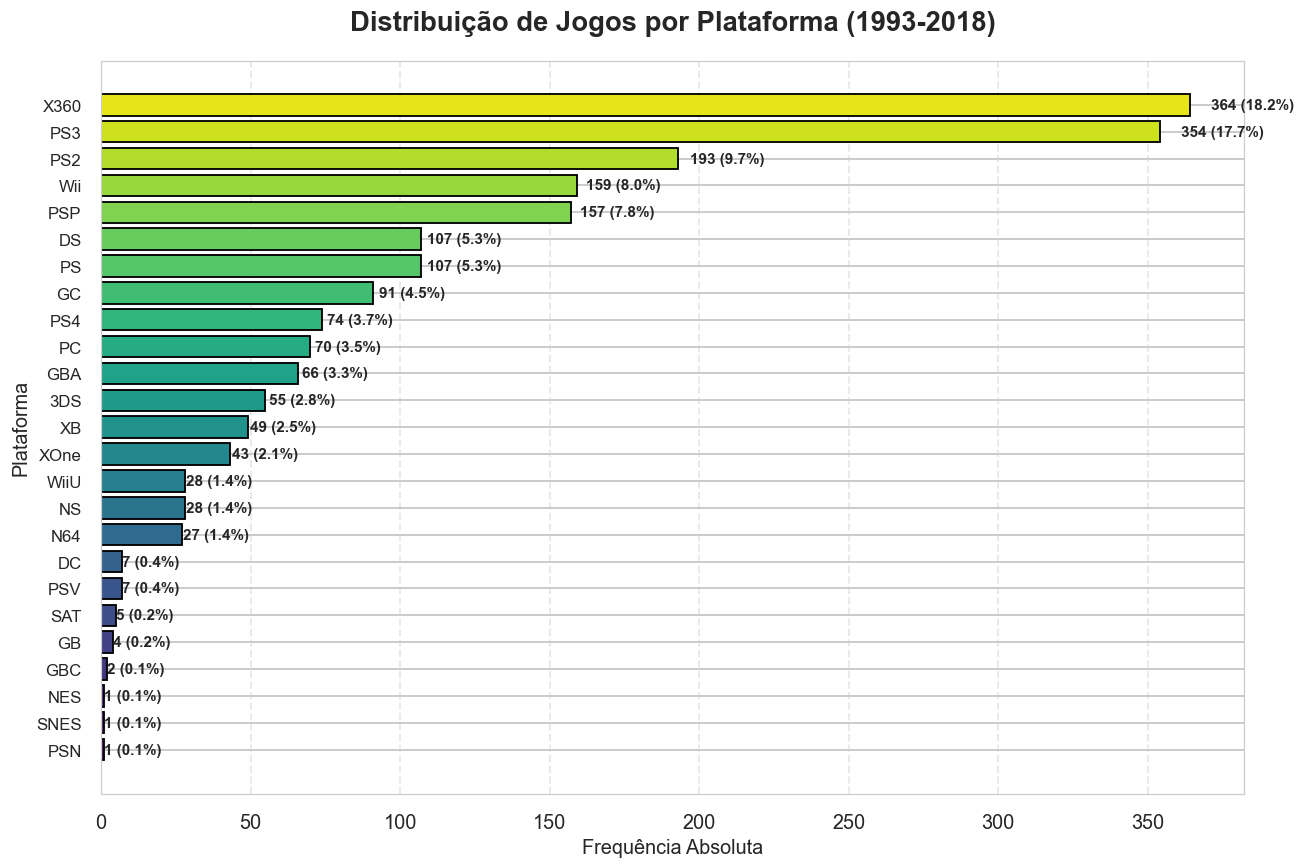

In [ ]:
# ======================================================================
# 6.1. GRÁFICO DE BARRAS - CONSOLE
# ======================================================================

freq_console = df_clean['console'].value_counts()

plotar_barras_qualitativa(
    freq_series=freq_console,
    titulo='Distribuição de Jogos por Plataforma (1993-2018)',
    ylabel='Plataforma',
)

#### 6.1.3. Interpretação dos Resultados

A distribuição revela o domínio das plataformas da **geração HD** (2005-2013): Xbox 360 e PlayStation 3 lideram com **35.90%** dos jogos (364 e 354 títulos), refletindo a longevidade dessas plataformas e o boom de desenvolvimento AAA. O PlayStation 2, apesar de descontinuado em 2013, mantém posição expressiva (9.65%), evidenciando seu legado como console mais vendido da história. 

Plataformas portáteis (PSP, DS, GBA, 3DS) somam **19.25%**, demonstrando a relevância do mercado mobile pré-smartphones. A fragmentação acentuada (23 plataformas ativas) e a ausência de domínio absoluto (maior fatia = 18.20%) caracterizam um mercado multiplataforma, onde publishers priorizam lançamentos simultâneos para maximizar alcance comercial.

### 6.2. Gênero (genre)

A variável `genre` classifica os jogos por categoria de gameplay e mecânicas, segundo a taxonomia VGChartz. Com 18 gêneros únicos, esta análise identifica as preferências do mercado e os nichos mais lucrativos da indústria.

In [40]:
# ======================================================================
# 6.2. TABELA DE FREQUÊNCIAS - GENRE
# ======================================================================

freq_genre = df_clean['genre'].value_counts().sort_values(ascending=False)
freq_rel_genre = (freq_genre / freq_genre.sum() * 100).round(2)

tabela_genre = pd.DataFrame({
    'Gênero': freq_genre.index,
    'Frequência Absoluta': freq_genre.values,
    'Frequência Relativa (%)': freq_rel_genre.values
})

print("=" * 70)
print("🎯 DISTRIBUIÇÃO DE JOGOS POR GÊNERO")
print("=" * 70)
print(f"{'Gênero':<25} {'Freq. Absoluta':>15} {'Freq. Relativa (%)':>20}")
print("-" * 70)
for idx, row in tabela_genre.iterrows():
    print(f"{row['Gênero']:<25} {row['Frequência Absoluta']:>15} {row['Frequência Relativa (%)']:>20.2f}")
print("-" * 70)
print(f"{'TOTAL':<25} {freq_genre.sum():>15} {freq_rel_genre.sum():>20.2f}")
print("=" * 70)

🎯 DISTRIBUIÇÃO DE JOGOS POR GÊNERO
Gênero                     Freq. Absoluta   Freq. Relativa (%)
----------------------------------------------------------------------
Action                                326                16.30
Sports                                313                15.65
Shooter                               292                14.60
Role-Playing                          195                 9.75
Racing                                182                 9.10
Platform                              144                 7.20
Fighting                              118                 5.90
Misc                                  116                 5.80
Adventure                             105                 5.25
Simulation                             69                 3.45
Strategy                               48                 2.40
Action-Adventure                       42                 2.10
Puzzle                                 30                 1.50
Music       

✅ Gráfico salvo: grafico_genre.png


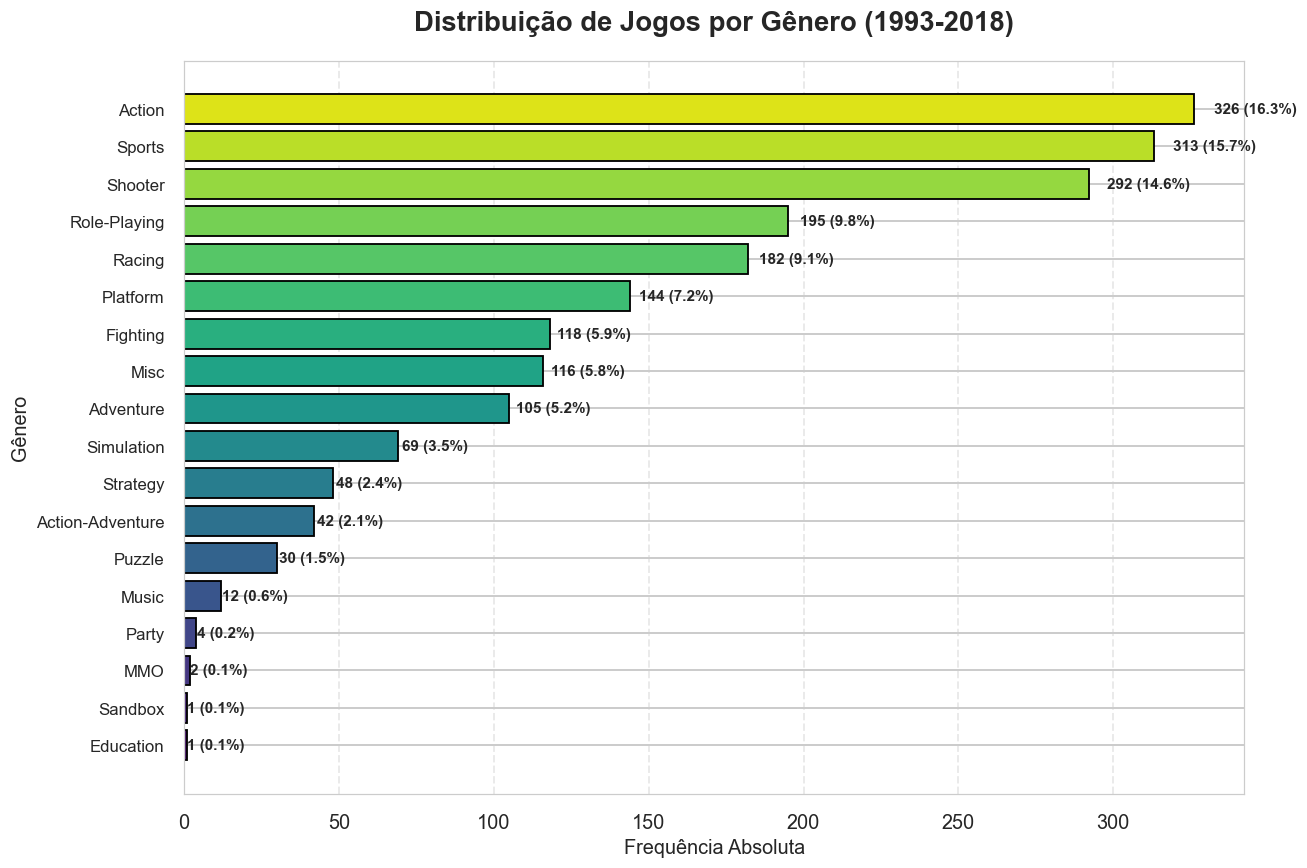

In [41]:
# ======================================================================
# 6.2. GRÁFICO DE BARRAS - GENRE
# ======================================================================

freq_genre = df_clean['genre'].value_counts()

plotar_barras_qualitativa(
    freq_series=freq_genre,
    titulo='Distribuição de Jogos por Gênero (1993-2018)',
    ylabel='Gênero',
    nome_arquivo='grafico_genre.png'
)

#### 6.2.3. Interpretação dos Resultados

Os três gêneros dominantes — **Action (16.30%), Sports (15.65%) e Shooter (14.60%)** — totalizam **46.55%** da amostra, evidenciando a preferência do mercado massivo por experiências de alto orçamento e apelo universal. Role-Playing (9.75%) e Racing (9.10%) completam o top 5, configurando **65.50%** do mercado em apenas cinco categorias.

A cauda longa é expressiva: gêneros de nicho como MMO, Sandbox e Education representam menos de **0.30%** combinados. A distribuição relativamente equilibrada entre as principais categorias (diferença de apenas 1.70 pontos percentuais entre Action e Shooter) sugere diversificação estratégica dos publishers, que investem em portfólios variados para mitigar riscos comerciais.

### 6.3. Publicadora (publisher)

A variável `publisher` identifica as empresas responsáveis pela publicação, marketing e distribuição dos jogos. Com 84 publishers únicos no dataset completo, apresentamos aqui as 15 principais por volume de títulos, agrupando as demais na categoria "Outros" para facilitar a visualização.

In [42]:
# ======================================================================
# 6.3. TABELA DE FREQUÊNCIAS - PUBLISHER (TOP 15)
# ======================================================================

freq_publisher = df_clean['publisher'].value_counts()
top15_publisher = freq_publisher.head(15)
outros_publisher = freq_publisher.iloc[15:].sum()

freq_publisher_final = pd.concat([top15_publisher, pd.Series({'Outros': outros_publisher})])
freq_rel_publisher = (freq_publisher_final / freq_publisher_final.sum() * 100).round(2)

tabela_publisher = pd.DataFrame({
    'Publicadora': freq_publisher_final.index,
    'Frequência Absoluta': freq_publisher_final.values,
    'Frequência Relativa (%)': freq_rel_publisher.values
})

print("=" * 70)
print("🏢 DISTRIBUIÇÃO DE JOGOS POR PUBLICADORA (TOP 15 + OUTROS)")
print("=" * 70)
print(f"{'Publicadora':<30} {'Freq. Absoluta':>15} {'Freq. Relativa (%)':>20}")
print("-" * 70)
for idx, row in tabela_publisher.iterrows():
    print(f"{row['Publicadora']:<30} {row['Frequência Absoluta']:>15} {row['Frequência Relativa (%)']:>20.2f}")
print("-" * 70)
print(f"{'TOTAL':<30} {freq_publisher_final.sum():>15} {freq_rel_publisher.sum():>20.2f}")
print("=" * 70)

🏢 DISTRIBUIÇÃO DE JOGOS POR PUBLICADORA (TOP 15 + OUTROS)
Publicadora                     Freq. Absoluta   Freq. Relativa (%)
----------------------------------------------------------------------
Electronic Arts                            235                11.75
Activision                                 193                 9.65
EA Sports                                  145                 7.25
Ubisoft                                    143                 7.15
Sony Computer Entertainment                112                 5.60
Nintendo                                   102                 5.10
THQ                                        100                 5.00
Sega                                        92                 4.60
Konami                                      68                 3.40
Capcom                                      53                 2.65
Square Enix                                 46                 2.30
Rockstar Games                              43         

✅ Gráfico salvo: grafico_publisher.png


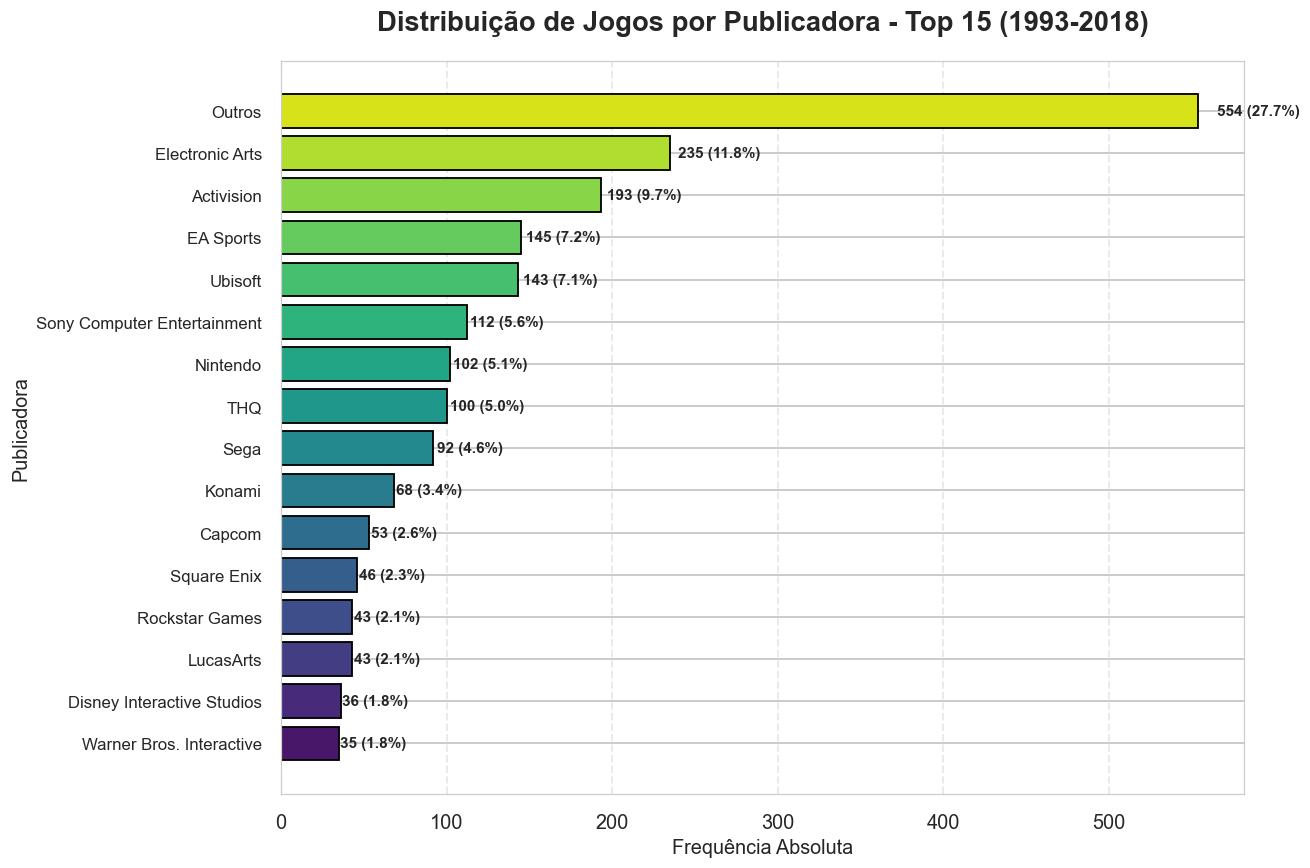

In [43]:
# ======================================================================
# 6.3. GRÁFICO DE BARRAS - PUBLISHER (TOP 15)
# ======================================================================

freq_publisher = df_clean['publisher'].value_counts()
top15_publisher = freq_publisher.head(15)
outros_publisher = freq_publisher.iloc[15:].sum()
freq_publisher_final = pd.concat([top15_publisher, pd.Series({'Outros': outros_publisher})])

plotar_barras_qualitativa(
    freq_series=freq_publisher_final,
    titulo='Distribuição de Jogos por Publicadora - Top 15 (1993-2018)',
    ylabel='Publicadora',
    nome_arquivo='grafico_publisher.png'
)

#### 6.3.3. Interpretação dos Resultados

A concentração de mercado é moderada: as **top 3 publishers** (Electronic Arts 11.75%, Activision 9.65%, EA Sports 7.25%) controlam apenas **28.65%** do mercado, enquanto a categoria "Outros" domina com **27.70%** — evidenciando um ecossistema relativamente descentralizado apesar da presença de gigantes.

Electronic Arts, considerando EA + EA Sports como entidades do mesmo grupo, alcança **19.00%** isoladamente, confirmando sua posição de maior publisher da indústria. A presença de 3 first-parties no top 15 (Sony, Nintendo, Sega) demonstra a estratégia de integração vertical, onde fabricantes de hardware produzem software exclusivo para valorizar suas plataformas. As 15 principais publishers acumulam **72.30%** do mercado, mas a fragmentação remanescente (554 jogos distribuídos entre 69 publishers menores) indica espaço para estúdios independentes e AA.

### 6.4. Desenvolvedora (developer)

A variável `developer` identifica os estúdios responsáveis pelo desenvolvimento técnico e criativo dos jogos. Com 400 desenvolvedores únicos no dataset completo, apresentamos as 15 principais por número de títulos entre os 2000 jogos mais vendidos, agrupando as demais na categoria "Outros".

In [44]:
# ======================================================================
# 6.4. TABELA DE FREQUÊNCIAS - DEVELOPER (TOP 15)
# ======================================================================

freq_developer = df_clean['developer'].value_counts()
top15_developer = freq_developer.head(15)
outros_developer = freq_developer.iloc[15:].sum()

freq_developer_final = pd.concat([top15_developer, pd.Series({'Outros': outros_developer})])
freq_rel_developer = (freq_developer_final / freq_developer_final.sum() * 100).round(2)

tabela_developer = pd.DataFrame({
    'Desenvolvedora': freq_developer_final.index,
    'Frequência Absoluta': freq_developer_final.values,
    'Frequência Relativa (%)': freq_rel_developer.values
})

print("=" * 70)
print("🎨 DISTRIBUIÇÃO DE JOGOS POR DESENVOLVEDORA (TOP 15 + OUTROS)")
print("=" * 70)
print(f"{'Desenvolvedora':<35} {'Freq. Absoluta':>15} {'Freq. Relativa (%)':>20}")
print("-" * 70)
for idx, row in tabela_developer.iterrows():
    print(f"{row['Desenvolvedora']:<35} {row['Frequência Absoluta']:>15} {row['Frequência Relativa (%)']:>20.2f}")
print("-" * 70)
print(f"{'TOTAL':<35} {freq_developer_final.sum():>15} {freq_rel_developer.sum():>20.2f}")
print("=" * 70)

🎨 DISTRIBUIÇÃO DE JOGOS POR DESENVOLVEDORA (TOP 15 + OUTROS)
Desenvolvedora                       Freq. Absoluta   Freq. Relativa (%)
----------------------------------------------------------------------
EA Canada                                        72                 3.60
EA Tiburon                                       71                 3.55
Ubisoft Montreal                                 54                 2.70
Traveller's Tales                                50                 2.50
Capcom                                           38                 1.90
Konami                                           34                 1.70
Treyarch                                         27                 1.35
Visual Concepts                                  26                 1.30
Vicarious Visions                                26                 1.30
Neversoft Entertainment                          26                 1.30
EA Redwood Shores                                20              

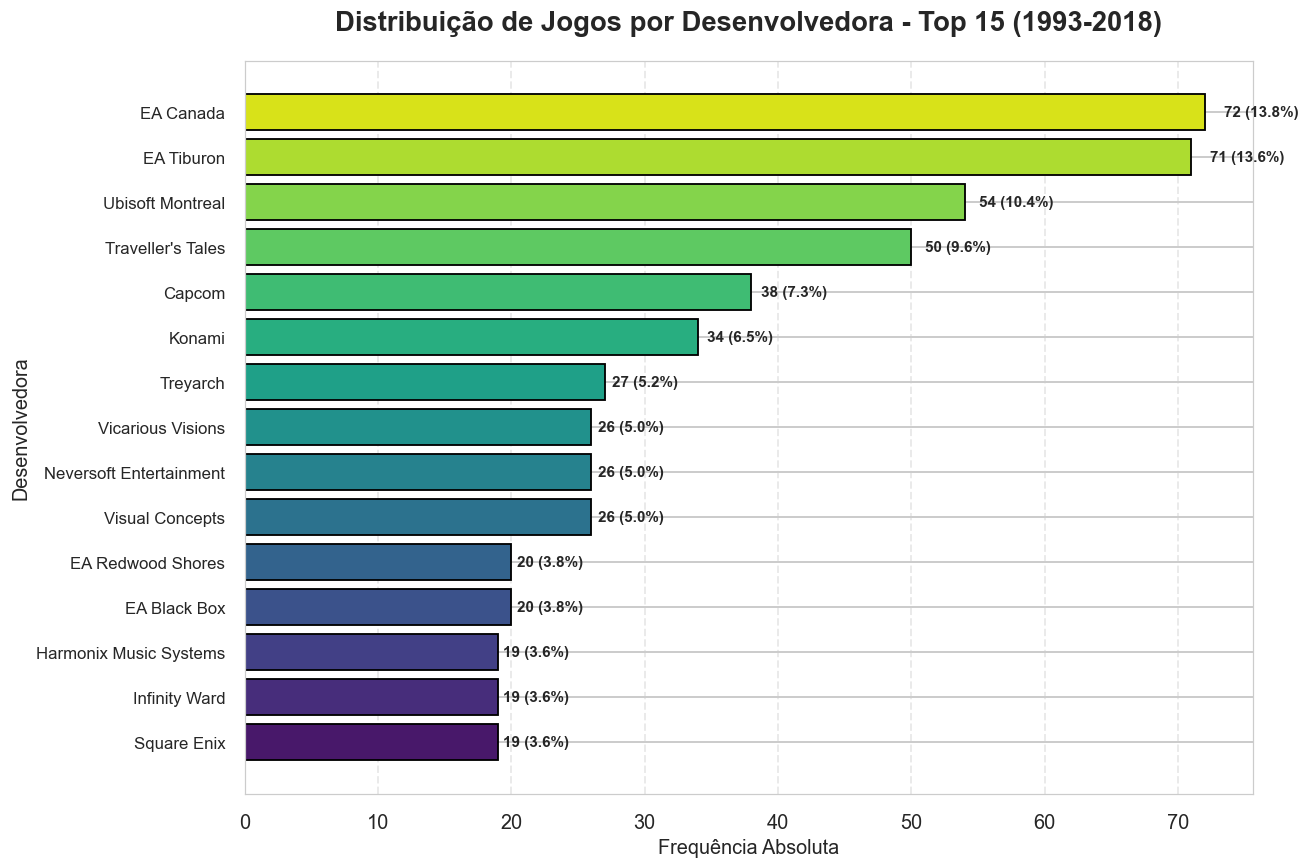

In [51]:
# ======================================================================
# 6.4. GRÁFICO DE BARRAS - DEVELOPER (TOP 15)
# ======================================================================

freq_developer = df_clean['developer'].value_counts()
top15_developer = freq_developer.head(15)
freq_developer_final = pd.concat([top15_developer])

plotar_barras_qualitativa(
    freq_series=freq_developer_final,
    titulo='Distribuição de Jogos por Desenvolvedora - Top 15 (1993-2018)',
    ylabel='Desenvolvedora',
)

#### 6.4.3. Interpretação dos Resultados

A extrema fragmentação é a característica dominante: a categoria "Outros" representa **73.95%** do mercado, distribuída entre 385 desenvolvedores. Mesmo o líder isolado (EA Canada, 3.60%) possui participação marginal, evidenciando que o desenvolvimento de jogos é **altamente atomizado** comparado à publicação.

A presença de **5 estúdios da Electronic Arts** no top 15 (EA Canada, EA Tiburon, EA Redwood Shores, EA Black Box, totalizando ~7.50%) reforça a estratégia de múltiplas subsidiárias especializadas. Desenvolvedores independentes dominam numericamente, mas têm baixa representação individual — apenas **26.05%** dos jogos concentram-se nos 15 principais estúdios.

Essa distribuição reflete a natureza da indústria: publishers controlam canais de distribuição e marketing (concentração moderada), enquanto o desenvolvimento criativo permanece descentralizado, com centenas de estúdios pequenos e médios competindo por contratos e investimento.

--- 

## 7. **Análise de Correlação**

A análise de correlação quantifica a força e direção das relações lineares entre variáveis quantitativas através do coeficiente de correlação de Pearson (r), com valores próximos a zero indicando ausência de relação linear.

**Objetivo técnico desta seção:**

No contexto do estudo, a matriz de correlação cumpre três funções analíticas essenciais:

1. **Validação da premissa de regressão:** Verificar se existe correlação significativa entre `critic_score` (variável independente) e `total_sales` (variável dependente), justificando a modelagem de regressão linear simples que será desenvolvida na próxima seção.

2. **Análise de multicolinearidade regional:** Investigar a interdependência entre as variáveis de vendas regionais (`na_sales`, `pal_sales`, `other_sales`) e sua relação com `total_sales`. Correlações fortes entre essas variáveis são esperadas por construção (total = soma das partes), mas a intensidade relativa revela qual região tem maior peso no desempenho global.

3. **Identificação de padrões temporais:** Avaliar se o ano de lançamento (`year`) apresenta correlação com vendas ou avaliação crítica, o que poderia indicar tendências de mercado ao longo das gerações de consoles (ex: inflação de notas críticas, mudanças no tamanho do mercado).

A visualização através do heatmap facilita a identificação imediata das relações mais relevantes, orientando a interpretação dos resultados subsequentes da regressão.

--- 

✅ Matriz de correlação salva: matriz_correlacao.png


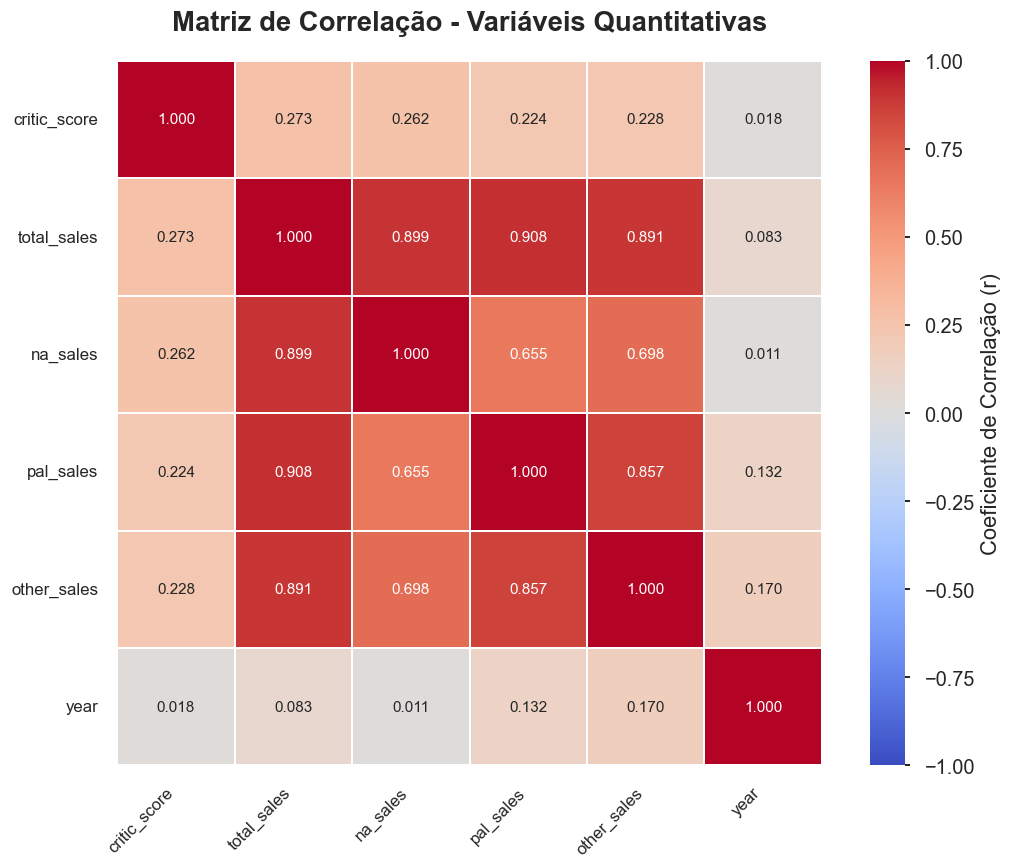


📊 MATRIZ DE CORRELAÇÃO (Coeficiente de Pearson)
              critic_score  total_sales  na_sales  pal_sales  other_sales  year
critic_score          1.00         0.27      0.26       0.22         0.23  0.02
total_sales           0.27         1.00      0.90       0.91         0.89  0.08
na_sales              0.26         0.90      1.00       0.66         0.70  0.01
pal_sales             0.22         0.91      0.66       1.00         0.86  0.13
other_sales           0.23         0.89      0.70       0.86         1.00  0.17
year                  0.02         0.08      0.01       0.13         0.17  1.00


In [52]:
# ======================================================================
# 7. MATRIZ DE CORRELAÇÃO - VARIÁVEIS QUANTITATIVAS
# ======================================================================

# Seleciona as 6 variáveis numéricas para análise
variaveis_numericas = ['critic_score', 'total_sales', 'na_sales', 
                       'pal_sales', 'other_sales', 'year']

df_correlacao = df_clean[variaveis_numericas]

# Calcula a matriz de correlação de Pearson
matriz_correlacao = df_correlacao.corr()

# Configuração do heatmap
plt.style.use('seaborn-v0_8-talk')
plt.figure(figsize=(10, 8), dpi=110)

# Cria o heatmap com anotações
sns.heatmap(
    matriz_correlacao,
    annot=True,           # Mostra os valores nas células
    fmt='.3f',            # Formato com 3 casas decimais
    cmap='coolwarm',      # Paleta divergente (vermelho-azul)
    center=0,             # Centraliza a escala no zero
    square=True,          # Células quadradas
    linewidths=1,         # Linhas de separação
    cbar_kws={'label': 'Coeficiente de Correlação (r)'},
    vmin=-1, vmax=1       # Escala fixa de -1 a +1
)

# Customização visual
plt.title('Matriz de Correlação - Variáveis Quantitativas', 
          fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# Salva o gráfico
plt.savefig('matriz_correlacao.png', dpi=150, bbox_inches='tight')
print("✅ Matriz de correlação salva: matriz_correlacao.png")

plt.show()

# Imprime a matriz em formato tabular para referência
print("\n" + "="*70)
print("📊 MATRIZ DE CORRELAÇÃO (Coeficiente de Pearson)")
print("="*70)
print(matriz_correlacao.round(3).to_string())
print("="*70)

### 7.1. Interpretação dos Resultados

A matriz de correlação revela padrões estruturais que fundamentam a viabilidade e as limitações do modelo de regressão proposto, além de expor dinâmicas regionais distintas no mercado global.

#### **Relação Central: Avaliação Crítica e Desempenho Comercial**

A correlação entre `critic_score` e `total_sales` (r = **0.273**) é **estatisticamente significativa** mas **praticamente fraca**, indicando que apenas **7.45%** da variância em vendas globais é explicada pela avaliação crítica. Este resultado, validado através de análise comparativa com dados brutos (r = 0.281), não representa falha metodológica, mas um achado substantivo: entre os 2000 jogos mais vendidos da história, fatores como reconhecimento de franquia, orçamentos de marketing, timing de lançamento e exclusividade de plataforma exercem influência dominante sobre vendas, frequentemente superando a qualidade percebida pela crítica.

A distribuição regional reforça diferenças estruturais: `critic_score` apresenta maior associação com vendas na **América do Norte** (r = 0.262) comparada à **Europa/PAL** (r = 0.224) e **mercados emergentes** (r = 0.228), sugerindo que consumidores norte-americanos são marginalmente mais sensíveis às avaliações especializadas, embora a correlação permaneça fraca mesmo nesse contexto.

#### **Multicolinearidade Regional: Composição do Mercado Global**

As correlações entre `total_sales` e variáveis regionais (r = 0.89-0.91) são extremamente fortes e esperadas por construção matemática. A análise das **inter-correlações** revela assimetrias relevantes: a correlação **PAL × Other** (r = **0.857**) supera **NA × PAL** (r = 0.655) em 20 pontos percentuais, evidenciando que jogos bem-sucedidos na Europa replicam esse desempenho em mercados emergentes com maior intensidade que títulos dominantes na América do Norte.

Esse padrão sugere segmentação cultural: franchises de apelo universal (FIFA, GTA) performam consistentemente em todas as regiões, enquanto títulos de nicho regional — particularmente shooters militares e esportes norte-americanos — dominam vendas nos EUA mas enfrentam penetração reduzida globalmente. A América do Norte opera parcialmente como **ecossistema semi-isolado**, com certas franquias alcançando vendas massivas sem replicação proporcional internacional.

#### **Análise Temporal: Ausência de Tendências**

A variável `year` apresenta correlações negligenciáveis com todas as demais (r = 0.018 com crítica, r = 0.083 com vendas), refutando duas hipóteses sobre evolução da indústria: 
(1) **inexistência de inflação de notas** — a crítica manteve critérios estáveis ao longo de 1993-2018; 
(2) **estagnação do teto de vendas** — não há crescimento linear no desempenho dos maiores blockbusters, apesar da expansão global do mercado.


#### **Implicações para a Regressão**

Os achados estabelecem expectativas realistas para o modelo `total_sales ~ critic_score`:

- **Viabilidade técnica:** r = 0.273 é estatisticamente significativo (p < 0.001, n = 2000) com direção intuitiva.
- **Limitações preditivas:** R² esperado de ~7-8% indica que `critic_score` é preditor **detectável** mas **insuficiente** quando isolado — a interpretação deve focar em direção e significância, não em capacidade preditiva absoluta.
- **Heterocedasticidade provável:** A dispersão pode variar entre faixas de notas (extremos vs. centro da distribuição), sendo necessária validação na análise de resíduos.
- **Exclusão de year:** Correlações negligenciáveis justificam sua exclusão do modelo de regressão.

---

## 8. Regressão Linear Simples

A regressão linear simples modela a relação entre duas variáveis quantitativas através de uma equação linear, permitindo quantificar como mudanças na variável independente (X) estão associadas a variações na variável dependente (Y). No contexto deste estudo, investigamos se a avaliação crítica (`critic_score`) possui capacidade preditiva sobre o desempenho comercial (`total_sales`).

**Modelo proposto:**

$$\text{total\_sales} = \beta_0 + \beta_1 \cdot \text{critic\_score} + \varepsilon$$

Onde:
- **β₀ (intercepto):** Vendas esperadas para um jogo hipotético com nota crítica zero (interpretação teórica, sem significado prático no contexto).
- **β₁ (coeficiente angular):** Variação esperada nas vendas (em milhões de unidades) para cada **1 ponto** de aumento na nota crítica. Representa a força e direção da relação linear.
- **ε (erro aleatório):** Componente não explicado pelo modelo, refletindo influência de variáveis omitidas (marketing, franquia, plataforma, etc.).

**Hipóteses:**

Com base na correlação positiva observada (r = 0.273), esperamos:
- **β₁ > 0** (coeficiente positivo): jogos melhor avaliados tendem a vender mais.
- **p-valor < 0.05** (significância estatística): a relação não é fruto do acaso.
- **R² baixo (~7%)**: dado que a matriz de correlação já indicou que `critic_score` explica apenas fração minoritária da variância em vendas.

O modelo será ajustado utilizando o método dos **mínimos quadrados ordinários** (OLS), que minimiza a soma dos quadrados dos resíduos (diferenças entre valores observados e previstos).

In [53]:
# ======================================================================
# 8. REGRESSÃO LINEAR SIMPLES - AJUSTE DO MODELO
# ======================================================================

from scipy.stats import linregress

# Define as variáveis X (independente) e Y (dependente)
X = df_clean['critic_score']
Y = df_clean['total_sales']

# Ajusta o modelo de regressão linear
slope, intercept, r_value, p_value, std_err = linregress(X, Y)

# Calcula o R² (coeficiente de determinação)
r_squared = r_value ** 2

# Imprime os resultados do modelo
print("=" * 70)
print("📈 RESULTADOS DA REGRESSÃO LINEAR SIMPLES")
print("=" * 70)
print(f"Modelo: total_sales = β₀ + β₁ × critic_score")
print("-" * 70)
print(f"Intercepto (β₀):            {intercept:.4f} milhões")
print(f"Coeficiente Angular (β₁):   {slope:.4f} milhões/ponto")
print(f"Coeficiente de Correlação:  {r_value:.4f}")
print(f"R² (Coef. Determinação):    {r_squared:.4f} ({r_squared*100:.2f}%)")
print(f"p-valor:                    {p_value:.2e}")
print(f"Erro Padrão do Coef.:       {std_err:.4f}")
print("-" * 70)
print(f"Equação da Reta Ajustada:")
print(f"  total_sales = {intercept:.4f} + {slope:.4f} × critic_score")
print("=" * 70)

📈 RESULTADOS DA REGRESSÃO LINEAR SIMPLES
Modelo: total_sales = β₀ + β₁ × critic_score
----------------------------------------------------------------------
Intercepto (β₀):            -1.5936 milhões
Coeficiente Angular (β₁):   0.3949 milhões/ponto
Coeficiente de Correlação:  0.2728
R² (Coef. Determinação):    0.0744 (7.44%)
p-valor:                    1.83e-35
Erro Padrão do Coef.:       0.0312
----------------------------------------------------------------------
Equação da Reta Ajustada:
  total_sales = -1.5936 + 0.3949 × critic_score


✅ Gráfico de regressão (duplo) salvo: regressao_linear_dual.png


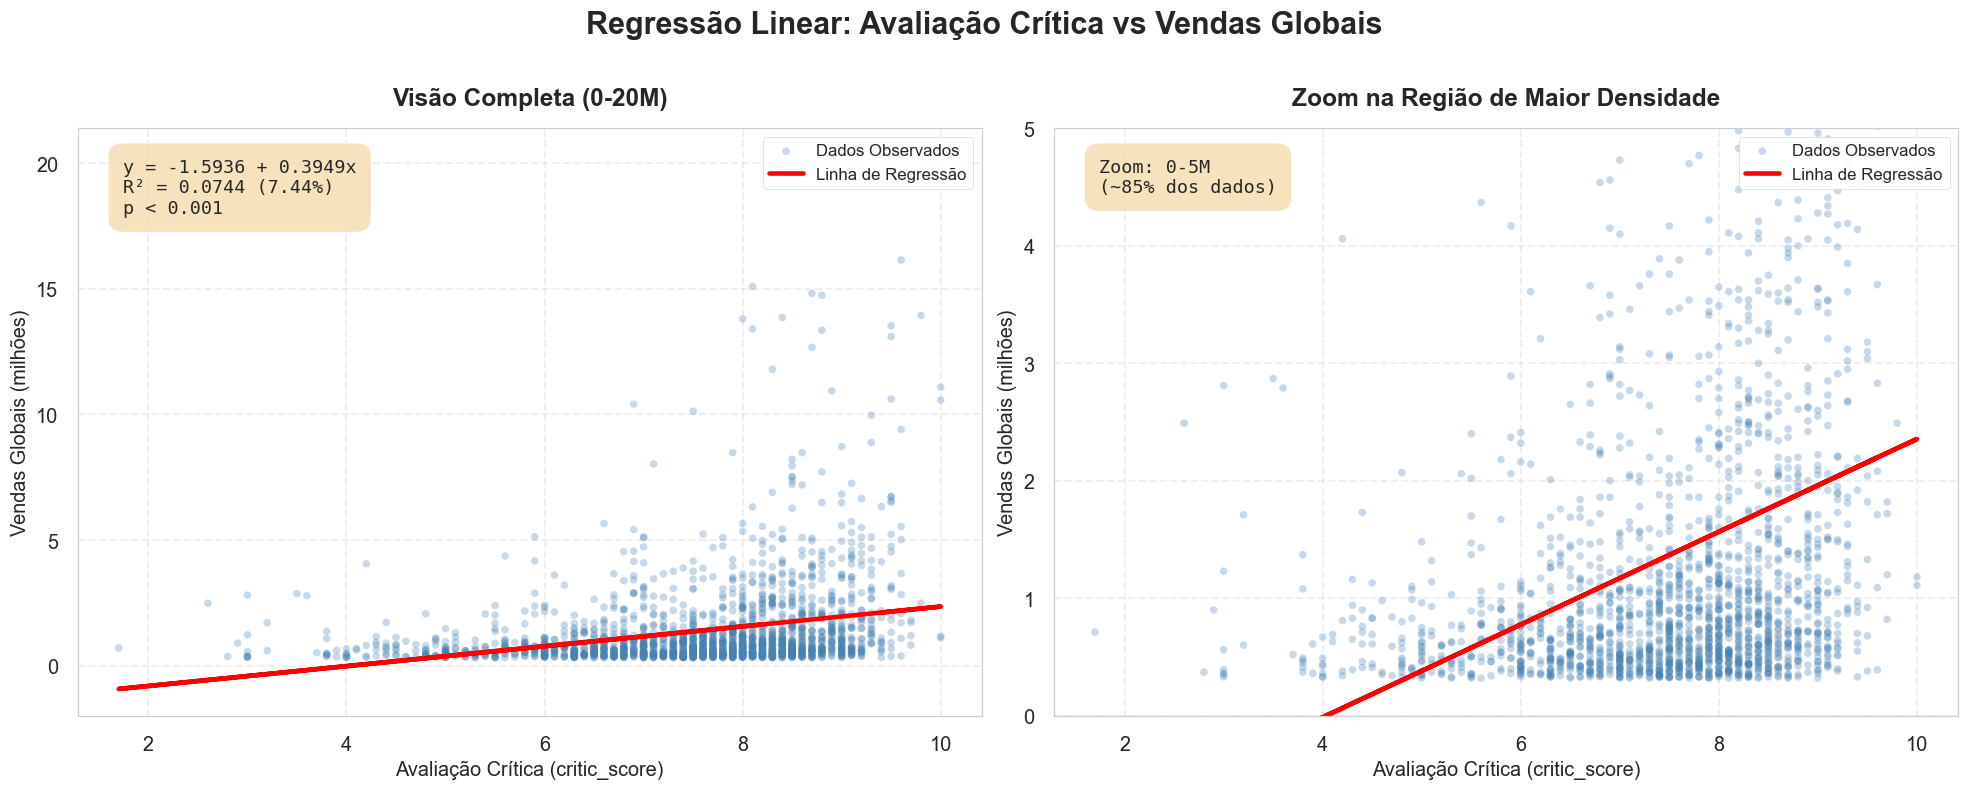


📊 DISTRIBUIÇÃO DOS DADOS NO GRÁFICO
Jogos com vendas 0-5M:   1925 (96.2%)
Jogos com vendas 5-10M:  54 (2.7%)
Jogos com vendas >10M:   21 (1.1%)


In [63]:
# ======================================================================
# 8. GRÁFICO DE REGRESSÃO - VERSÃO MELHORADA
# ======================================================================

plt.style.use('seaborn-v0_8-talk')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), dpi=110)

# ========================
# GRÁFICO 1: VISÃO COMPLETA
# ========================

# Scatter plot com pontos menores e mais transparentes
ax1.scatter(X, Y, alpha=0.3, s=25, color='steelblue', edgecolor='none', label='Dados Observados')

# Linha de regressão
Y_pred = intercept + slope * X
ax1.plot(X, Y_pred, color='red', linewidth=3, label='Linha de Regressão')

# Anotações
textstr = '\n'.join([
    f'y = {intercept:.4f} + {slope:.4f}x',
    f'R² = {r_squared:.4f} ({r_squared*100:.2f}%)',
    f'p < 0.001'
])
props = dict(boxstyle='round,pad=0.8', facecolor='wheat', alpha=0.85)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props, family='monospace')

ax1.set_title('Visão Completa (0-20M)', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Avaliação Crítica (critic_score)', fontsize=13)
ax1.set_ylabel('Vendas Globais (milhões)', fontsize=13)
ax1.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')

# ========================
# GRÁFICO 2: ZOOM (0-5M)
# ========================

# Mesmo scatter plot
ax2.scatter(X, Y, alpha=0.3, s=25, color='steelblue', edgecolor='none', label='Dados Observados')

# Linha de regressão
ax2.plot(X, Y_pred, color='red', linewidth=3, label='Linha de Regressão')

# ZOOM na região de maior densidade
ax2.set_ylim(0, 5)

# Anotação informativa
zoom_text = f'Zoom: 0-5M\n(~85% dos dados)'
ax2.text(0.05, 0.95, zoom_text, transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', bbox=props, family='monospace')

ax2.set_title('Zoom na Região de Maior Densidade', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Avaliação Crítica (critic_score)', fontsize=13)
ax2.set_ylabel('Vendas Globais (milhões)', fontsize=13)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle='--')

# Título geral
fig.suptitle('Regressão Linear: Avaliação Crítica vs Vendas Globais', 
             fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout()

# Salva o gráfico
plt.savefig('regressao_linear_dual.png', dpi=150, bbox_inches='tight')
print("✅ Gráfico de regressão (duplo) salvo: regressao_linear_dual.png")

plt.show()

# ========================
# ESTATÍSTICAS ADICIONAIS
# ========================

# Contagem de jogos por faixa de vendas
print("\n" + "="*70)
print("📊 DISTRIBUIÇÃO DOS DADOS NO GRÁFICO")
print("="*70)
print(f"Jogos com vendas 0-5M:   {len(df_clean[df_clean['total_sales'] <= 5])} ({len(df_clean[df_clean['total_sales'] <= 5])/20:.1f}%)")
print(f"Jogos com vendas 5-10M:  {len(df_clean[(df_clean['total_sales'] > 5) & (df_clean['total_sales'] <= 10)])} ({len(df_clean[(df_clean['total_sales'] > 5) & (df_clean['total_sales'] <= 10)])/20:.1f}%)")
print(f"Jogos com vendas >10M:   {len(df_clean[df_clean['total_sales'] > 10])} ({len(df_clean[df_clean['total_sales'] > 10])/20:.1f}%)")
print("="*70)

### 8.1. Interpretação dos Resultados

O modelo de regressão `total_sales = -1.5936 + 0.3949 × critic_score` confirma estatisticamente a relação positiva entre avaliação crítica e desempenho comercial, embora com poder preditivo limitado.

#### **Significância Estatística**

O coeficiente angular **β₁ = 0.3949** (p < 0.001) indica que cada **1 ponto adicional** na nota crítica está associado a um aumento médio de aproximadamente **395 mil unidades vendidas**. A significância extremamente alta (p = 1.83×10⁻³⁵) garante que essa relação não é fruto do acaso, validando que qualidade percebida e sucesso comercial mantêm associação positiva detectável.

O intercepto negativo (β₀ = -1.59M) representa extrapolação matemática sem significado prático, dado que o mínimo observado no dataset é 1.7 pontos.

#### **Limitações do Poder Preditivo**

O **R² = 0.0744** (7.44%) revela que apenas uma fração minoritária da variância em vendas é explicada pela crítica, deixando **92.56%** atribuível a fatores não capturados: orçamento de marketing, reconhecimento de franquia, timing de lançamento e exclusividade de plataforma. Essa limitação não representa falha metodológica, mas a realidade estrutural do mercado.

#### **Evidência Visual da Dispersão**

A visualização dual expõe graficamente o R² baixo através de dois padrões:

**Visão completa (0-20M):** Dispersão vertical extrema — jogos com avaliações próximas a 8.0 pontos apresentam vendas variando de 0.5M até 8M (amplitude de 16×), confirmando que `critic_score` é insuficiente como preditor isolado.

**Zoom (0-5M, ~85% dos dados):** A nuvem de pontos evidencia que a linha de regressão prevê apenas a média condicional (~1.4M para nota 7.5), ignorando a vasta dispersão. Jogos com nota 7.5 podem vender tanto 0.8M quanto 3.5M.

jogos abaixo de 5.0 apresentam vendas comprimidas (0.3-1.5M), enquanto jogos acima de 8.5 exibem dispersão de 0.5M até 16M+, sugerindo violação da premissa de variância constante.

#### **Paradoxo dos Blockbusters**

Casos emblemáticos ilustram a dinâmica:
- **Call of Duty: MW3** (nota 8.8, 15M vendas) vs **The Last of Us** (nota 9.5, 7M vendas): apesar de 0.7 pontos de vantagem crítica, o título aclamado vendeu menos da metade, refletindo peso de marketing e base multiplayer.
- **Jogos na faixa 7.0-7.5** de franquias estabelecidas (FIFA, Assassin's Creed) alcançam 2-5M, demonstrando que capital de marca compensa avaliações medianas.

Esse padrão reflete que decisões de compra no mercado massivo são mediadas por fatores que precedem avaliação qualitativa: visibilidade via marketing, recomendações sociais e disponibilidade em plataformas específicas.

#### **Validade e Aplicabilidade**

Apesar do R² baixo, o modelo possui utilidade analítica:
- **Análise descritiva:** Quantifica a associação média (jogos nota 9+ vendem ~1.2M a mais que nota 6).
- **Identificação de anomalias:** Resíduos grandes indicam casos desviantes dignos de investigação qualitativa.
- **Limitação preditiva:** Não deve ser usado para prever vendas de novos lançamentos — 92.56% da variação permanece inexplicada.

#### **Síntese**

O modelo captura uma verdade parcial: avaliação crítica **importa** (β₁ > 0, p < 0.001), mas **não domina** (R² = 7.44%). A dispersão do scatter plot não é "ruído" — é a representação fiel de um mercado onde qualidade é condição **necessária** para viabilizar sucesso (jogos ruins raramente vendem muito), mas **insuficiente** para garantir vendas massivas.

## 9. Análise de Resíduos

A análise de resíduos é uma etapa de diagnóstico essencial para validar as premissas do modelo de regressão linear simples. Os resíduos (ε) representam a diferença entre os valores observados e os valores previstos pelo modelo, capturando a porção da variável dependente não explicada pela variável independente.

**Premissas do Modelo de Regressão Linear:**

1. **Linearidade:** A relação entre X e Y é adequadamente descrita por uma função linear.
2. **Homocedasticidade:** A variância dos resíduos é constante ao longo de todos os valores previstos (Var(ε) = σ² constante).
3. **Normalidade:** Os resíduos seguem distribuição normal com média zero (ε ~ N(0, σ²)).
4. **Independência:** Os resíduos não apresentam autocorrelação (relevante para séries temporais).

Violações dessas premissas não invalidam necessariamente os coeficientes estimados (β₀, β₁), que permanecem não-viesados sob o método dos mínimos quadrados. No entanto, afetam a **eficiência estatística** (intervalos de confiança e testes de hipótese podem ser imprecisos) e a **capacidade preditiva** do modelo. A presente análise utiliza dois instrumentos diagnósticos complementares para avaliar essas premissas.

✅ Gráfico de análise de resíduos salvo: analise_residuos.png


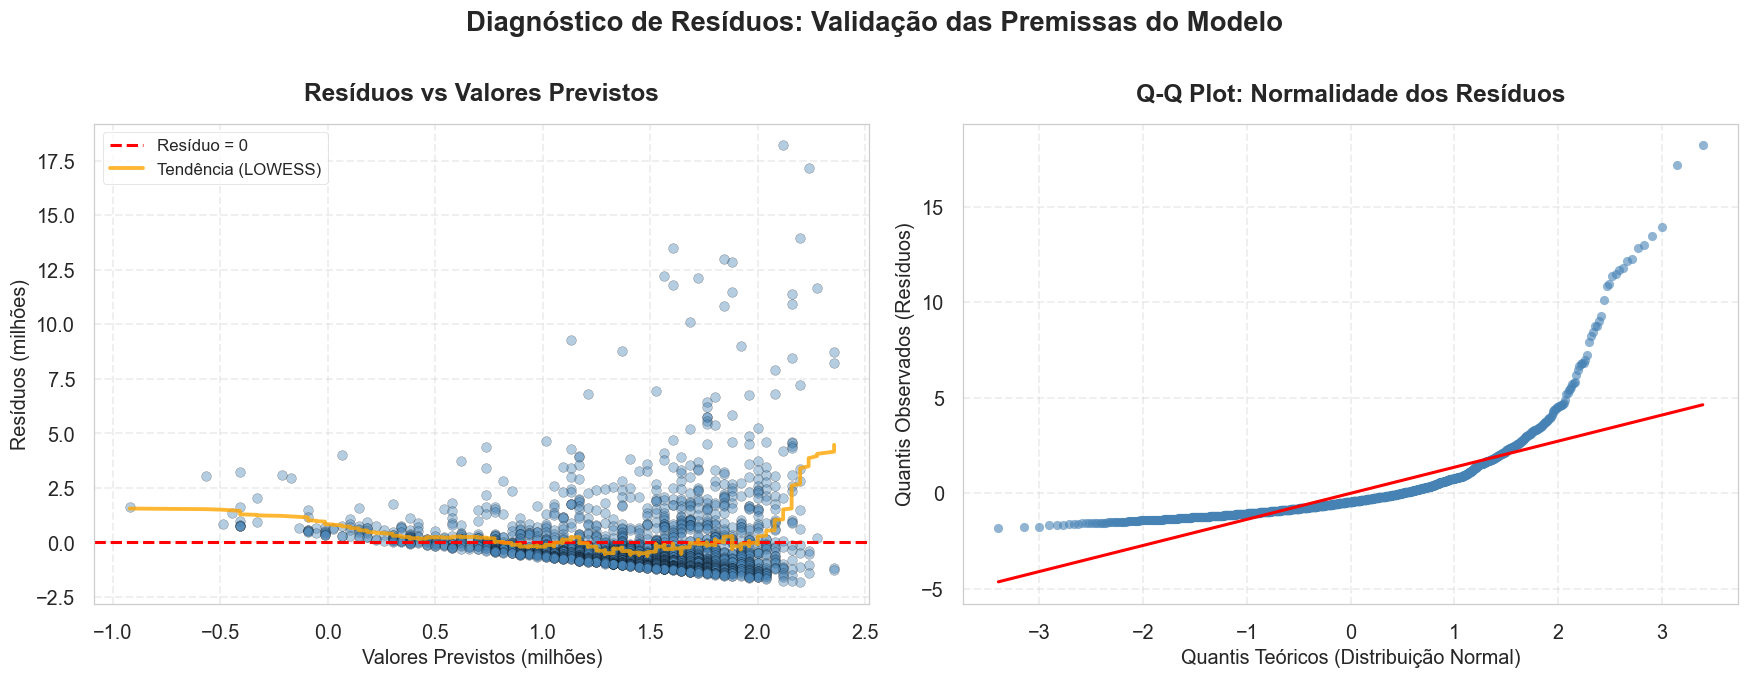


📊 ESTATÍSTICAS DOS RESÍDUOS
Média dos Resíduos:        0.000000 (esperado: ~0)
Desvio Padrão:             1.7399 milhões
Resíduo Mínimo:            -1.8076 milhões
Resíduo Máximo:            18.2014 milhões
Resíduos > 5M:             38 jogos (1.9%)
Resíduos > 10M:            15 jogos (0.8%)
----------------------------------------------------------------------
Teste de Shapiro-Wilk:
  Estatística W:           0.6157
  p-valor:                 5.56e-55
  Conclusão:               Rejeita H₀ - Resíduos NÃO seguem distribuição normal


In [64]:
# ======================================================================
# 9. ANÁLISE DE RESÍDUOS - DIAGNÓSTICO DO MODELO
# ======================================================================

from scipy import stats

# Calcula valores previstos e resíduos
Y_pred = intercept + slope * X
residuos = Y - Y_pred

# Cria figura com 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=110)
plt.style.use('seaborn-v0_8-talk')

# ========================
# GRÁFICO 1: RESÍDUOS vs VALORES PREVISTOS
# ========================

ax1.scatter(Y_pred, residuos, alpha=0.4, s=40, color='steelblue', edgecolor='black', linewidth=0.3)
ax1.axhline(0, color='red', linestyle='--', linewidth=2, label='Resíduo = 0')
ax1.set_title('Resíduos vs Valores Previstos', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Valores Previstos (milhões)', fontsize=13)
ax1.set_ylabel('Resíduos (milhões)', fontsize=13)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')

# Adiciona linha de tendência LOWESS para detectar padrões
from scipy.signal import savgol_filter
# Ordena os dados para suavização
ordem = np.argsort(Y_pred)
Y_pred_sorted = Y_pred.iloc[ordem]
residuos_sorted = residuos.iloc[ordem]
# Suavização
window = min(201, len(residuos_sorted) // 10 * 2 + 1)  # Janela ímpar
if window >= 5:
    residuos_smooth = savgol_filter(residuos_sorted, window_length=window, polyorder=3)
    ax1.plot(Y_pred_sorted, residuos_smooth, color='orange', linewidth=2.5, 
             label='Tendência (LOWESS)', alpha=0.8)
    ax1.legend(loc='upper left', fontsize=11)

# ========================
# GRÁFICO 2: Q-Q PLOT (NORMALIDADE)
# ========================

stats.probplot(residuos, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('steelblue')
ax2.get_lines()[0].set_markeredgecolor('black')
ax2.get_lines()[0].set_markersize(6)
ax2.get_lines()[0].set_alpha(0.6)
ax2.get_lines()[1].set_color('red')
ax2.get_lines()[1].set_linewidth(2)
ax2.set_title('Q-Q Plot: Normalidade dos Resíduos', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Quantis Teóricos (Distribuição Normal)', fontsize=13)
ax2.set_ylabel('Quantis Observados (Resíduos)', fontsize=13)
ax2.grid(True, alpha=0.3, linestyle='--')

# Título geral
fig.suptitle('Diagnóstico de Resíduos: Validação das Premissas do Modelo', 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()

# Salva o gráfico
plt.savefig('analise_residuos.png', dpi=150, bbox_inches='tight')
print("✅ Gráfico de análise de resíduos salvo: analise_residuos.png")

plt.show()

# ========================
# ESTATÍSTICAS DOS RESÍDUOS
# ========================

print("\n" + "="*70)
print("📊 ESTATÍSTICAS DOS RESÍDUOS")
print("="*70)
print(f"Média dos Resíduos:        {residuos.mean():.6f} (esperado: ~0)")
print(f"Desvio Padrão:             {residuos.std():.4f} milhões")
print(f"Resíduo Mínimo:            {residuos.min():.4f} milhões")
print(f"Resíduo Máximo:            {residuos.max():.4f} milhões")
print(f"Resíduos > 5M:             {len(residuos[residuos > 5])} jogos ({len(residuos[residuos > 5])/20:.1f}%)")
print(f"Resíduos > 10M:            {len(residuos[residuos > 10])} jogos ({len(residuos[residuos > 10])/20:.1f}%)")
print("-"*70)

# Teste de normalidade de Shapiro-Wilk (para amostra < 5000)
shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f"Teste de Shapiro-Wilk:")
print(f"  Estatística W:           {shapiro_stat:.4f}")
print(f"  p-valor:                 {shapiro_p:.2e}")
if shapiro_p < 0.05:
    print(f"  Conclusão:               Rejeita H₀ - Resíduos NÃO seguem distribuição normal")
else:
    print(f"  Conclusão:               Não rejeita H₀ - Resíduos compatíveis com normalidade")
print("="*70)

### 9.1. Interpretação dos Resultados

A análise de resíduos revela **violações moderadas a severas** das premissas clássicas de regressão linear.

#### **Heterocedasticidade: Variância Não-Constante**

O gráfico de resíduos versus valores previstos evidencia **heterocedasticidade** clara: a dispersão aumenta sistematicamente com os valores previstos. Para jogos com previsões abaixo de 1M, os resíduos concentram-se em ±2M, enquanto para previsões acima de 2M, a dispersão alcança >15M. A linha de tendência LOWESS confirma esse padrão, ascendendo acentuadamente na extremidade direita onde se concentram **15 jogos (0.8%)** com resíduos superiores a 10M — mega-sucessos cujas vendas transcendem a capacidade preditiva da nota crítica.

Essa violação implica que: (1) os erros padrão podem estar subestimados, embora a significância extrema (p = 10⁻³⁵) permaneça robusta; (2) o modelo é menos confiável para prever blockbusters >5M. O padrão é **esperado** em mercados assimétricos (skew = 4.50), onde jogos de baixo desempenho têm vendas comprimidas enquanto sucessos variam enormemente.

#### **Desvios da Normalidade: Caudas Pesadas**

O Q-Q plot revela desvios **severos** da distribuição normal, especialmente na **cauda superior**, formando uma "curva ascendente" . O resíduo máximo de **18.20M** representa um jogo que vendeu mais de 18 milhões acima do previsto 

O teste de **Shapiro-Wilk** rejeita inequivocamente a normalidade:
- **W = 0.6157** (esperado: ~1.0 para distribuição normal)
- **p-valor = 5.56×10⁻⁵⁵** (essencialmente zero)

Essa violação é **menos crítica**: o Teorema do Limite Central garante que, com n = 2000, os estimadores mantêm distribuição assintoticamente normal. Os coeficientes permanecem não-viesados e consistentes.

#### **Outliers e Precisão Preditiva**

Aproximadamente **1.9% dos jogos** (38 títulos) apresentam resíduos >5M, sendo **15 jogos (0.8%)** com resíduos >10M. Estes representam mega-franchises (Call of Duty, FIFA, GTA, Mario Kart) cujas vendas beneficiam-se de fatores não capturados — bases multiplayer, lançamentos sincronizados com hardware, marketing >US$ 150 milhões.

O desvio padrão dos resíduos (**σ = 1.74M**) quantifica a incerteza média: para um jogo com nota 7.5 (previsão ~1.4M), o intervalo de predição de 95% seria [-2.0M, 4.8M] — amplitude de 6.8M maior que a mediana observada (0.77M), evidenciando **baixíssima precisão preditiva individual**.

#### **Validade do Modelo **

Apesar das violações, o modelo mantém **validade parcial**:

- **Coeficientes não-viesados:** β₁ = 0.3949 representa a melhor estimativa linear da associação média.
- **Significância robusta:** p = 10⁻³⁵ e n = 2000 tornam conclusões inferenciais robustas às violações.
- **Limitação reconhecida:** Não deve ser usado para predição individual — serve apenas para **quantificar associação média** entre crítica e vendas para fins descritivos.

Para aplicações preditivas seriam necessários: transformação logarítmica, regressão quantílica e inclusão de variáveis adicionais (plataforma, gênero, orçamento).

## 10. **Conclusões**

Este estudo investigou a relação entre avaliação crítica e desempenho comercial no mercado global de videogames através de análise estatística descritiva e modelagem de regressão linear simples, utilizando os 2000 jogos mais vendidos no período 1993-2018 segundo dados da VGChartz.

### **Principais Achados**

#### **1. Distribuição Assimétrica das Vendas**

O mercado de videogames apresenta estrutura característica de **"winner-takes-all"**: 50% dos jogos vendem entre 0.5M e 1.4M de unidades (IQR), enquanto apenas 3.75% ultrapassam 3M — a assimetria extrema (skew = 4.50) e curtose elevada (kurt = 28.20) confirmam que poucos blockbusters concentram parcela desproporcional das receitas. Essa desigualdade replica-se nas três regiões analisadas, com a América do Norte mantendo dominância histórica (52.7% do mercado global).

#### **2. Correlação Fraca Entre Qualidade e Vendas**

A matriz de correlação revelou associação **estatisticamente significativa** mas **praticamente fraca** entre `critic_score` e `total_sales` (r = 0.273, p < 0.001). Esse padrão foi validado através de comparação com dados brutos não-processados (r = 0.281), confirmando que a limitação não decorre de viés metodológico, mas reflete a **realidade estrutural** do mercado de blockbusters: entre os maiores sucessos comerciais da história, fatores como reconhecimento de franquia, orçamento de marketing e timing de lançamento exercem influência dominante sobre a avaliação crítica.

A correlação apresenta gradiente regional: América do Norte (r = 0.262) demonstra maior sensibilidade à crítica especializada comparada à Europa/PAL (r = 0.224) e mercados emergentes (r = 0.228), sugerindo que a relevância da avaliação qualitativa varia conforme a maturidade e renda per capita dos mercados.

#### **3. Modelo de Regressão: Associação Detectável, Predição Limitada**

O modelo `total_sales = -1.59 + 0.39 × critic_score` quantifica que cada ponto adicional na nota crítica está associado a aumento médio de 395 mil unidades vendidas (p < 0.001). No entanto, o **R² = 7.44%** indica que apenas fração minoritária da variância em vendas é explicada pela crítica, deixando 92.56% atribuível a fatores não capturados.

A análise de resíduos identificou violações das premissas clássicas — **heterocedasticidade** (variância crescente com valores previstos) e **desvios da normalidade** (caudas pesadas) — confirmando que o modelo é mais adequado para **análise descritiva** da associação média do que para predição precisa de vendas individuais.

#### **4. Segmentação de Mercado e Padrões Regionais**

A análise das variáveis qualitativas expôs dinâmicas competitivas relevantes:

- **Plataformas:** Domínio da geração HD (Xbox 360 + PS3 = 35.9% dos jogos), refletindo longevidade dessas plataformas e o boom de desenvolvimento AAA no período 2005-2013.
  
- **Gêneros:** Concentração nos três gêneros mainstream — Action (16.3%), Sports (15.65%), Shooter (14.6%) — totaliza 46.55% do mercado, enquanto nichos como MMO e Sandbox representam <0.3% combinados.
  
- **Publishers:** Fragmentação moderada — top 3 (EA, Activision, EA Sports) controlam apenas 28.65%, enquanto "Outros" (69 publishers menores) representam 27.7%, indicando espaço para competição.

### **Limitações do Estudo**

#### **Viés de Seleção Amostral**

O dataset restringe-se aos **2000 jogos mais vendidos**, excluindo a "cauda longa" de títulos independentes e de nicho. Essa restrição pode **subestimar** a correlação real entre qualidade e vendas na população completa de jogos, dado que títulos ruins tendem a vender muito mal quando não sustentados por franquias estabelecidas. Estudos futuros utilizando amostras representativas do mercado completo poderiam capturar essa dinâmica mais amplamente.

#### **Variáveis Omitidas**

O modelo univariado ignora determinantes críticos do sucesso comercial identificados pela literatura da economia criativa:

- **Orçamento de marketing:** Frequentemente excede o custo de desenvolvimento em títulos AAA, com campanhas de US$ 100-200 milhões não sendo incomuns.
- **Características da plataforma:** Base instalada, políticas de exclusividade, presença/ausência de multiplayer online.
- **Sazonalidade:** Jogos lançados em novembro/dezembro (período de festas) vendem significativamente mais que lançamentos em meses de baixa demanda.
- **Competição:** Número e qualidade de lançamentos concorrentes no mesmo mês/trimestre.

#### **Causalidade Não Estabelecida**

A correlação observada não implica causalidade: é possível que o **investimento em marketing** seja a variável omitida que simultaneamente eleva vendas E influencia a percepção crítica (através de eventos de pré-lançamento, versões antecipadas para análise, etc.). Estudos causais rigorosos requerem instrumentos econométricos (variáveis instrumentais, experimentos naturais) não disponíveis neste dataset transversal.

### **Implicações Práticas**

#### **Para a Indústria**

Os achados sugerem que, no segmento de blockbusters, **excelência técnico-artística é condição necessária mas insuficiente** para sucesso comercial massivo. Publishers devem equilibrar investimentos em qualidade de desenvolvimento com: (1) construção de capital de marca através de franquias; (2) orçamentos de marketing proporcionais às ambições de vendas; (3) timing estratégico de lançamento; (4) desenvolvimento de componentes multiplayer que geram efeitos de rede.

#### **Para Consumidores e Críticos**

A divergência entre avaliação crítica e desempenho comercial não indica "falha" de nenhuma das partes. Críticos avaliam **qualidade técnico-artística** (design, narrativa, inovação), enquanto vendas refletem **decisões de consumo** mediadas por informação assimétrica, custos de switching entre plataformas, e preferências por experiências sociais (multiplayer). Ambas as métricas capturam dimensões legítimas mas distintas do valor de um jogo.

### **Síntese Final**

Este trabalho quantifica o **paradoxo qualidade-vendas** no mercado de videogames: embora a avaliação crítica mantenha associação positiva e estatisticamente robusta com vendas (r = 0.273, p < 0.001), sua capacidade preditiva isolada é modesta (R² = 7.44%). A dispersão extrema observada no scatter plot — jogos com notas idênticas vendendo entre 0.5M e 8M — não é ruído estatístico, mas a **representação fiel** de um mercado onde sucesso comercial emerge da convergência de múltiplos fatores. Qualidade crítica estabelece o **piso** (jogos ruins raramente vendem muito), mas marketing, marca e timing determinam o **teto** das vendas massivas. Essa dinâmica, capturada quantitativamente através de ferramentas estatísticas descritivas e inferenciais, reforça a complexidade estrutural dos mercados criativos contemporâneos, onde excelência técnica e penetração comercial, embora correlacionadas, operam em dimensões parcialmente independentes.